# Curva de demanda segundo o método do livro — Minerva

Este notebook estima a relação entre preço e volume do `Produto_A` seguindo a sequência
metodológica apresentada por Phillips: separar ajuste e teste, comparar formas funcionais
simples, acrescentar variáveis pelo processo *champion-challenger* e avaliar o modelo
congelado fora da amostra.

A análise é autocontida. Suas hipóteses e critérios vêm do documento
`docs/referencias/Minerva_Unifesp_ITA.pdf`, dos achados exploratórios documentados em
`notebooks/1.0-minerva-eda-preparacao.ipynb` e das referências bibliográficas listadas ao final.

## 1. Contrato analítico

O documento do Desafio Minerva-Unifesp-ITA solicita uma curva que transforme preços diários em volumes previstos para que
uma etapa posterior maximize margem sob metas semanais e limites de variação de preço.
Phillips propõe começar com preço e demanda, comparar curvas lineares, exponenciais e de
elasticidade constante e somente depois incorporar variáveis adicionais.

O período de 01/08/2025 a 31/10/2025 será o desenvolvimento. Os dez dias de 03/11/2025 a
14/11/2025 formam o holdout oficial e não serão carregados antes do congelamento do modelo.
Dentro do desenvolvimento, o corte 52/24 fornece a primeira comparação transparente. A decisão
é então repetida em três janelas expansivas semanais:

- corte inicial com 52 observações de ajuste e 24 de validação;
- folds expansivos 39/13, 52/13 e 65/11 para medir generalização e sobreajuste;
- 10 observações oficiais mantidas fora da seleção nesta execução.

O objetivo é preditivo. Como os preços históricos não foram randomizados, nenhuma
associação será automaticamente interpretada como efeito causal.

O EDA fornece a origem empírica dos challengers: dia da semana, mês, quinzena, semana do
mês e tendência temporal. O documento da Minerva acrescenta a hipótese de início do mês.
Essas fontes formulam candidatos; nenhuma delas escolhe antecipadamente o modelo final.


**Preparação do ambiente.** Os caminhos de saída recebem o sufixo `livro` ou o prefixo
`02b`, identificando os produtos deste método. As bibliotecas estatísticas são carregadas
antes dos dados para tornar explícitas as dependências da execução.

In [1]:
from pathlib import Path
import hashlib
import json
import os
import platform

ROOT = Path.cwd()
if not (ROOT / 'data').exists():
    ROOT = ROOT.parent
os.chdir(ROOT)
os.environ.setdefault('MPLCONFIGDIR', '/tmp/minerva-matplotlib')
os.environ.setdefault('XDG_CACHE_HOME', '/tmp/minerva-cache')
Path(os.environ['MPLCONFIGDIR']).mkdir(parents=True, exist_ok=True)
Path(os.environ['XDG_CACHE_HOME']).mkdir(parents=True, exist_ok=True)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from IPython.display import display
from scipy import stats
from statsmodels.stats.diagnostic import acorr_ljungbox, het_breuschpagan
from statsmodels.stats.stattools import durbin_watson

DATA_PATH = ROOT / 'data/processed/minerva_modelagem_treino.csv'
HOLDOUT_PATH = ROOT / 'data/interim/minerva_holdout.csv'
MODELS_DIR = ROOT / 'models'
FIGURES_DIR = ROOT / 'reports/figures'
TABLES_DIR = ROOT / 'reports/tables'
PROCESSED_DIR = ROOT / 'data/processed'
for directory in [MODELS_DIR, FIGURES_DIR, TABLES_DIR, PROCESSED_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

CHAMPION_PATH = MODELS_DIR / 'demand_curve_champion_livro.json'
UNCERTAINTY_PATH = MODELS_DIR / 'demand_curve_uncertainty_livro.json'
SELECTION_PATH = MODELS_DIR / 'model_selection_summary_livro.json'
HOLDOUT_PREDICTIONS_PATH = PROCESSED_DIR / 'minerva_previsoes_holdout_livro.csv'

ORDEM_DIAS = ['Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta', 'Sábado', 'Domingo']
CUTOFF_VALIDACAO = pd.Timestamp('2025-10-06')
SEMENTE = 42

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 40)

def salvar_json(payload, path):
    Path(path).write_text(
        json.dumps(payload, ensure_ascii=False, indent=2, sort_keys=True) + '\n',
        encoding='utf-8',
    )

def carregar_json(path):
    return json.loads(Path(path).read_text(encoding='utf-8'))

def arquivo_sha256(path):
    digest = hashlib.sha256()
    with Path(path).open('rb') as arquivo:
        for bloco in iter(lambda: arquivo.read(1024 * 1024), b''):
            digest.update(bloco)
    return digest.hexdigest()

print(f'Python {platform.python_version()}')
print(f'Dados de desenvolvimento: {DATA_PATH}')
print(f'Holdout reservado: {HOLDOUT_PATH}')

Python 3.13.15
Dados de desenvolvimento: /Users/ngodeny/Documents/mestrado/202602-resolucao_problemas/data/processed/minerva_modelagem_treino.csv
Holdout reservado: /Users/ngodeny/Documents/mestrado/202602-resolucao_problemas/data/interim/minerva_holdout.csv


**Resultado da preparação.** O ambiente utiliza o arquivo de desenvolvimento preparado na etapa de dados,
mas cria modelos, tabelas, figuras e previsões com nomes exclusivos. A simples definição do
caminho do holdout não realiza sua leitura.

## 2. Leitura exclusiva do desenvolvimento

A separação temporal precisa ocorrer antes de qualquer inspeção do período oficial. Também
é necessário confirmar positividade de preço e volume, pois os modelos exponencial e de
elasticidade constante utilizam logaritmos. A variável `inicio_mes` é definida previamente
como os sete primeiros dias corridos, traduzindo a hipótese de início do mês citada no documento do Desafio Minerva-Unifesp-ITA.

In [2]:
dados = pd.read_csv(DATA_PATH, parse_dates=['data', 'inicio_semana'])
dados = dados.sort_values('data').reset_index(drop=True)

colunas_obrigatorias = {
    'produto', 'data', 'volume_kg', 'preco_kg', 'dia_semana',
    'fim_semana', 'indice_tempo', 'inicio_semana',
}
ausentes = colunas_obrigatorias - set(dados.columns)
if ausentes:
    raise ValueError(f'Colunas obrigatórias ausentes: {sorted(ausentes)}')
if dados['data'].duplicated().any():
    raise ValueError('Há datas duplicadas no desenvolvimento.')
if dados[['volume_kg', 'preco_kg']].isna().any().any():
    raise ValueError('Preço ou volume contém valor ausente.')
if (dados[['volume_kg', 'preco_kg']] <= 0).any().any():
    raise ValueError('Preço e volume devem ser estritamente positivos.')
if len(dados) != 76 or dados['data'].max() != pd.Timestamp('2025-10-31'):
    raise ValueError('O desenvolvimento não corresponde aos 76 dias esperados.')

dados['inicio_mes'] = (dados['data'].dt.day <= 7).astype(int)

auditoria = pd.DataFrame({
    'Indicador': [
        'Observações', 'Produto', 'Data inicial', 'Data final',
        'Preço mínimo', 'Preço máximo', 'Volume mínimo', 'Volume máximo',
        'Dias de início do mês',
    ],
    'Resultado': [
        len(dados), dados['produto'].unique().tolist(),
        dados['data'].min().date(), dados['data'].max().date(),
        dados['preco_kg'].min(), dados['preco_kg'].max(),
        dados['volume_kg'].min(), dados['volume_kg'].max(),
        int(dados['inicio_mes'].sum()),
    ],
})
display(auditoria)

,Indicador,Resultado
0,Observações,76
1,Produto,[Produto_A]
2,Data inicial,2025-08-01
3,Data final,2025-10-31
4,Preço mínimo,1188.863746
5,Preço máximo,1365.491261
6,Volume mínimo,0.588008
7,Volume máximo,100.0
8,Dias de início do mês,17


**Resultado da leitura.** O desenvolvimento contém 76 observações válidas de um único SKU,
com preços entre aproximadamente R$ 1.188,86/kg e R$ 1.365,49/kg e volumes positivos. Isso
permite estimar as três formas propostas pelo livro. A base não informa ruptura de estoque;
por isso, tratar vendas como demanda permanece uma hipótese operacional explícita.

## 3. Primeiro corte temporal interno

O holdout oficial deve permanecer fora da seleção. Para reproduzir inicialmente a lógica
treino-teste do livro dentro dos 76 dias, o corte é colocado no início de uma semana. As primeiras
52 observações ajustam os candidatos e as 24 seguintes produzem uma comparação cronologicamente
posterior. Esse corte facilita a leitura, mas não decide sozinho: a seção 7.1 repetirá a avaliação em
três folds temporais expansivos.


In [3]:
ajuste = dados.loc[dados['data'] < CUTOFF_VALIDACAO].copy()
validacao = dados.loc[dados['data'] >= CUTOFF_VALIDACAO].copy()

if len(ajuste) != 52 or len(validacao) != 24:
    raise ValueError('A divisão interna esperada é 52/24.')

divisao = pd.DataFrame({
    'Conjunto': ['Ajuste interno', 'Validação interna', 'Holdout oficial reservado'],
    'Observações': [len(ajuste), len(validacao), 10],
    'Início': [ajuste['data'].min().date(), validacao['data'].min().date(), '03/11/2025'],
    'Fim': [ajuste['data'].max().date(), validacao['data'].max().date(), '14/11/2025'],
    'Uso': ['Estimar parâmetros', 'Selecionar candidatos', 'Avaliar modelo congelado'],
})
display(divisao)

,Conjunto,Observações,Início,Fim,Uso
0,Ajuste interno,52,2025-08-01,2025-10-05,Estimar parâmetros
1,Validação interna,24,2025-10-06,2025-10-31,Selecionar candidatos
2,Holdout oficial reservado,10,03/11/2025,14/11/2025,Avaliar modelo congelado


**Resultado da divisão.** O ajuste termina em 05/10/2025 e a validação cobre 06/10 a
31/10/2025. A validação contém quatro semanas finais do desenvolvimento e preserva a ordem
temporal. Nenhum dado de novembro foi necessário para estabelecer esse protocolo.

Como um único período pode favorecer uma variável sazonal por acaso, seus resultados serão tratados
como provisórios até a comparação nas janelas expansivas.


## 4. Funções de estimação e avaliação

As métricas centrais do livro são RMSE, MAPE e WMAPE. MAE, sMAPE, viés, BIC e AICc são
apresentados como diagnósticos complementares. BIC e AICc só serão comparados entre modelos
ajustados na mesma escala de resposta; não serão usados para declarar uma forma funcional
superior a outra.

Nos modelos transformados, a previsão volta para quilogramas com o fator de *smearing* de
Duan estimado apenas no conjunto de ajuste. Essa correção evita o viés de simplesmente
exponenciar a média prevista em log e não modifica a elasticidade estimada.

In [4]:
MAPAS_CONTEXTO = {
    'none': {dia: 'Geral' for dia in ORDEM_DIAS},
    'weekend': {
        dia: ('Fim_de_semana' if dia in ['Sábado', 'Domingo'] else 'Dia_util')
        for dia in ORDEM_DIAS
    },
    'weekday': {dia: dia for dia in ORDEM_DIAS},
    'grouped': {
        dia: (
            'Segunda_a_Quinta' if dia in ORDEM_DIAS[:4]
            else 'Sexta' if dia == 'Sexta'
            else 'Fim_de_semana'
        )
        for dia in ORDEM_DIAS
    },
    'grouped4': {
        dia: (
            'Segunda' if dia == 'Segunda'
            else 'Terca_a_Quinta' if dia in ORDEM_DIAS[1:4]
            else 'Sexta' if dia == 'Sexta'
            else 'Fim_de_semana'
        )
        for dia in ORDEM_DIAS
    },
}
ORDEM_CONTEXTO = {
    'none': ['Geral'],
    'weekend': ['Dia_util', 'Fim_de_semana'],
    'weekday': ORDEM_DIAS,
    'grouped': ['Segunda_a_Quinta', 'Sexta', 'Fim_de_semana'],
    'grouped4': ['Terca_a_Quinta', 'Segunda', 'Sexta', 'Fim_de_semana'],
}

def matriz_desenho(base, specification):
    family = specification['family']
    calendar = specification.get('calendar', 'none')
    interaction = specification.get('interaction', False)
    matriz = pd.DataFrame(index=base.index)
    matriz['const'] = 1.0
    if family == 'power':
        price_name = 'ln_preco'
        matriz[price_name] = np.log(base['preco_kg'])
    else:
        price_name = 'preco'
        matriz[price_name] = base['preco_kg']

    contexto = base['dia_semana'].map(MAPAS_CONTEXTO[calendar])
    for nome in ORDEM_CONTEXTO[calendar][1:]:
        dummy = (contexto == nome).astype(float)
        matriz[f'contexto_{nome}'] = dummy
        if interaction:
            matriz[f'{price_name}_x_{nome}'] = matriz[price_name] * dummy

    if specification.get('start_month', False):
        matriz['inicio_mes'] = base['inicio_mes'].astype(float)
    if specification.get('trend', False):
        matriz['indice_tempo_10'] = base['indice_tempo'] / 10
    if specification.get('month', False):
        for mes in [9, 10]:
            matriz[f'mes_{mes}'] = (base['mes'] == mes).astype(float)
    if specification.get('fortnight', False):
        matriz['segunda_quinzena'] = (base['quinzena'] == '2ª quinzena').astype(float)
    if specification.get('week_of_month', False):
        for semana in [2, 3, 4, 5]:
            matriz[f'semana_mes_{semana}'] = (base['semana_mes'] == semana).astype(float)
    return matriz

def resposta_modelo(base, family):
    if family in {'exponential', 'power'}:
        return np.log(base['volume_kg'])
    return base['volume_kg']

def ajustar_modelo(base, specification, robust=False):
    matriz = matriz_desenho(base, specification)
    resposta = resposta_modelo(base, specification['family'])
    modelo = sm.OLS(resposta, matriz).fit(cov_type='HC3' if robust else 'nonrobust')
    smearing = (
        float(np.exp(modelo.resid).mean())
        if specification['family'] in {'exponential', 'power'}
        else 1.0
    )
    return modelo, smearing

def prever_modelo(modelo, smearing, nova_base, specification):
    previsao = np.asarray(
        modelo.predict(matriz_desenho(nova_base, specification)), dtype=float
    )
    if specification['family'] in {'exponential', 'power'}:
        previsao = np.exp(previsao) * smearing
    return previsao

def calcular_metricas(real, previsto):
    real = np.asarray(real, dtype=float)
    previsto = np.asarray(previsto, dtype=float)
    erro = previsto - real
    return {
        'MAE': float(np.mean(np.abs(erro))),
        'RMSE': float(np.sqrt(np.mean(erro**2))),
        'MAPE': float(np.mean(np.abs(erro) / real)),
        'WMAPE': float(np.sum(np.abs(erro)) / np.sum(real)),
        'sMAPE': float(np.mean(2 * np.abs(erro) / (np.abs(real) + np.abs(previsto)))),
        'Viés (%)': float(np.sum(erro) / np.sum(real)),
        'Previsão mínima': float(np.min(previsto)),
        'Previsões não positivas': int(np.sum(previsto <= 0)),
    }

def avaliar_especificacao(codigo, specification):
    modelo, smearing = ajustar_modelo(ajuste, specification)
    previsto = prever_modelo(modelo, smearing, validacao, specification)
    metricas = calcular_metricas(validacao['volume_kg'], previsto)
    quantidade_parametros = len(modelo.params)
    tamanho = len(ajuste)
    aicc = (
        modelo.aic
        + 2 * quantidade_parametros * (quantidade_parametros + 1)
        / (tamanho - quantidade_parametros - 1)
    )
    price_name = 'ln_preco' if specification['family'] == 'power' else 'preco'
    return {
        'Código': codigo,
        'Família': specification['family'],
        'Calendário': specification.get('calendar', 'none'),
        'Início do mês': specification.get('start_month', False),
        'Tendência': specification.get('trend', False),
        'Mês': specification.get('month', False),
        'Quinzena': specification.get('fortnight', False),
        'Semana do mês': specification.get('week_of_month', False),
        'Interações de preço': specification.get('interaction', False),
        'Parâmetros': quantidade_parametros,
        'Inclinação-base': float(modelo.params[price_name]),
        'p-valor inclinação-base': float(modelo.pvalues[price_name]),
        'R² na escala de ajuste': float(modelo.rsquared),
        'BIC na escala de ajuste': float(modelo.bic),
        'AICc na escala de ajuste': float(aicc),
        'Smearing': smearing,
        **metricas,
    }, previsto, modelo, smearing

print('Funções definidas para estimação, previsão e comparação temporal.')

Funções definidas para estimação, previsão e comparação temporal.


**Resultado da definição.** Todos os candidatos usarão exatamente as mesmas observações de
ajuste e validação. Modelos que produzam volume não positivo serão marcados como inadequados
para a otimização, mesmo que alguma métrica média pareça favorável.

## 4.1 Verificação passo a passo contra as seções 4.2 e 4.3

O quadro abaixo separa o que é reprodução direta do procedimento de Phillips do que precisa ser
adaptado à base da Minerva. Essa distinção é importante porque o livro apresenta regressão logística
somente quando existe demanda potencial e, portanto, uma taxa de conversão observável.

| Passo no livro | Procedimento de Phillips | Tradução neste projeto | Situação |
|---|---|---|---|
| 4.2.1 — modelo mínimo | Começar com preço como único preditor e comparar as formas linear, exponencial e elasticidade constante. | Ajustar as três formas no corte 52/24 e repetir a decisão nas janelas expansivas. | Reprodução com validação adicional. |
| 4.2.1 — escala de avaliação | Retornar as previsões à escala de demanda e comparar RMSE, MAPE e WMAPE no teste. | Comparar em quilogramas, acrescentando MAE, sMAPE e viés; aplicar *smearing* nas formas logarítmicas. | Reprodução com diagnósticos adicionais. |
| 4.2.2 — logit | Modelar a conversão \(d/D\) quando a demanda potencial \(D\) fornece o denominador. | A base contém somente volume realizado; não existe \(D\), taxa de conversão nem resposta binomial. | Não aplicável; logit não é estimado. |
| 4.3.1 — preparação | Limpar preço e demanda e investigar censura por falta de estoque. | Validar datas, positividade e completude; registrar que não há informação de estoque. | Parcial pela ausência de estoque. |
| 4.3.2 — treino e teste | Separar dados para detectar *overfitting*. | Usar folds 39/13, 52/13 e 65/11, sem embaralhamento, e preservar o holdout de 10 dias. | Reprodução adaptada à ordem temporal. |
| 4.3.3 — champion-challenger | Partir de modelo simples, acrescentar variáveis e cruzamentos e promover somente melhora no teste. | Congelar primeiro a forma e o calendário; depois desafiar com variáveis do EDA e do documento da Minerva. | Reprodução com parcimônia explícita. |
| 4.3.3 — regressão logística | O texto usa regressão logística na descrição geral do processo. | Como a resposta é volume contínuo e não conversão, estimar OLS na escala exigida por cada forma de 4.2.1. | Adaptação necessária ao tipo de resposta. |
| 4.3.3 — reestimação | Reestimar o campeão usando treino e teste depois de encerrar a seleção. | Reestimar nos 76 dias de desenvolvimento antes de abrir o holdout oficial. | Reprodução direta. |

Assim, o procedimento segue o *champion-challenger* do livro, mas não força regressão logística em
uma variável que não é binária nem uma proporção. A forma log-log é uma das três curvas comparadas,
não um substituto informal para o logit.


## 5. Primeira rodada: o modelo mínimo de preço

Phillips chama de modelo mínimo interessante uma função de demanda explicada somente pelo preço,
isto é, \(d(p)=f(p)\). Isso não significa escolher imediatamente uma única forma. A seção 4.2.1
compara três candidatos mínimos:

- `MIN_PRECO_LINEAR`: \(Q=\alpha+\beta P\);
- `MIN_PRECO_EXPONENCIAL`: \(\log Q=\alpha+\beta P\);
- `MIN_PRECO_LOGLOG`: \(\log Q=\alpha+\beta\log P\).

O prefixo `MIN_PRECO` significa **preço como único preditor**. No terceiro modelo, \(\beta\) é
diretamente a elasticidade-preço. A decisão será tomada na escala original de quilogramas, não pelo
R² calculado em respostas diferentes.


,Família,Parâmetros,Inclinação-base,p-valor inclinação-base,R² na escala de ajuste,MAE,RMSE,MAPE,WMAPE,sMAPE,Viés (%),Previsão mínima
Código,,,,,,,,,,,,
MIN_PRECO_LINEAR,linear,2,-0.0570,0.4074,0.0138,20.1467,27.4582,496.0265,71.6970,88.1738,-34.6850,12.8937
MIN_PRECO_EXPONENCIAL,exponential,2,-0.0025,0.6631,0.0038,20.3994,27.7599,501.1041,72.5963,89.1020,-34.4522,14.2907
MIN_PRECO_LOGLOG,power,2,-3.2085,0.6648,0.0038,20.4072,27.7466,503.1509,72.6242,89.1057,-34.2782,14.4137


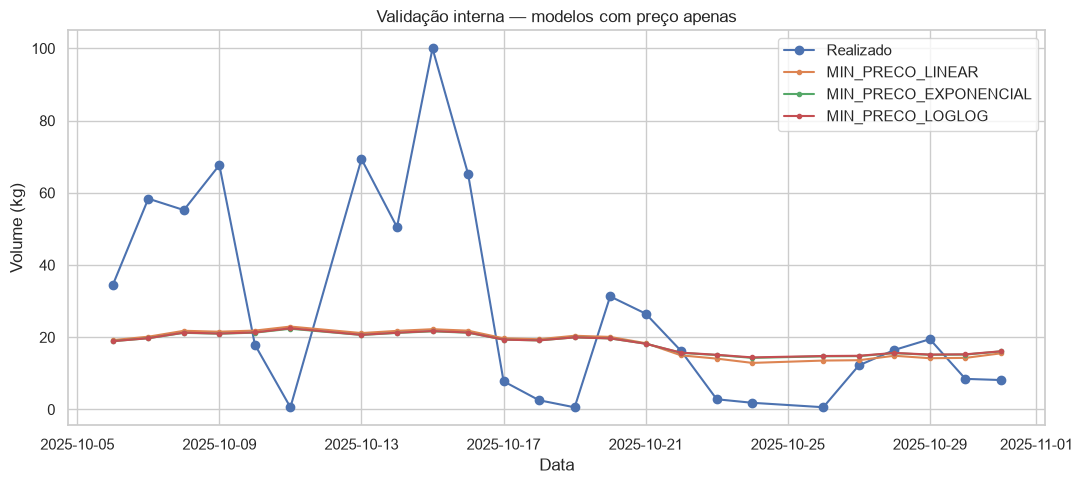

In [5]:
FORMAS = {
    'MIN_PRECO_LINEAR': {'family': 'linear', 'calendar': 'none'},
    'MIN_PRECO_EXPONENCIAL': {'family': 'exponential', 'calendar': 'none'},
    'MIN_PRECO_LOGLOG': {'family': 'power', 'calendar': 'none'},
}

linhas_forma = []
previsoes_forma = {}
for codigo, specification in FORMAS.items():
    linha, previsto, _, _ = avaliar_especificacao(codigo, specification)
    linhas_forma.append(linha)
    previsoes_forma[codigo] = previsto

ranking_forma = pd.DataFrame(linhas_forma).set_index('Código').sort_values('WMAPE')
ranking_forma.to_csv(TABLES_DIR / '02b_formas_preco_apenas.csv')

exibicao_forma = ranking_forma[[
    'Família', 'Parâmetros', 'Inclinação-base', 'p-valor inclinação-base',
    'R² na escala de ajuste', 'MAE', 'RMSE', 'MAPE', 'WMAPE', 'sMAPE',
    'Viés (%)', 'Previsão mínima',
]].copy()
for coluna in ['MAPE', 'WMAPE', 'sMAPE', 'Viés (%)']:
    exibicao_forma[coluna] *= 100
display(exibicao_forma.round(4))

figura, eixo = plt.subplots(figsize=(11, 5))
eixo.plot(validacao['data'], validacao['volume_kg'], marker='o', label='Realizado')
for codigo, previsto in previsoes_forma.items():
    eixo.plot(validacao['data'], previsto, marker='.', label=codigo)
eixo.set(
    title='Validação interna — modelos com preço apenas',
    xlabel='Data', ylabel='Volume (kg)',
)
eixo.legend()
figura.tight_layout()
figura.savefig(FIGURES_DIR / '02b_formas_preco_apenas.png', dpi=160, bbox_inches='tight')
plt.show()

**Resultado da primeira rodada.** A linear obteve WMAPE de `71,70%`; a exponencial,
`72,60%`; e a elasticidade constante, `72,62%`. A diferença inferior a um ponto percentual
não caracteriza vitória substantiva, e os três erros são altos. O preço sozinho não explica
a sazonalidade diária indicada pela Minerva. Em vez de fixar uma família por uma diferença
marginal, as três seguem para o mesmo desafio de calendário.

## 6. Segunda rodada: calendário sob as três formas

O documento do Desafio Minerva-Unifesp-ITA descreve diferenças de volume ao longo da semana.
O EDA da base confirmou visualmente e por triagem controlada que dia da semana é a principal
hipótese de nível, com separação marcante entre segunda–quinta, sexta e fim de semana. A partir
dessas duas fontes, cinco estruturas são definidas antes da comparação:

- `CAL0_SEM_CALENDARIO`: nenhum calendário;
- `CAL1_UTIL_FDS`: dia útil versus fim de semana;
- `CAL2_SETE_DIAS`: sete dias separados;
- `CAL3_SEGQUI_SEX_FDS`: segunda–quinta, sexta e fim de semana;
- `CAL4_SEG_TERQUI_SEX_FDS`: segunda, terça–quinta, sexta e fim de semana.

Cada estrutura será aplicada às três famílias. A tabela identifica explicitamente família,
calendário, número de parâmetros e validade das previsões.

,Forma exibida,Estrutura exibida,Parâmetros,Válido para demanda,Previsões não positivas,MAE,RMSE,MAPE,WMAPE,sMAPE,BIC na escala de ajuste,AICc na escala de ajuste
Código,,,,,,,,,,,,
elasticidade-constante | CAL3_SEGQUI_SEX_FDS,elasticidade-constante,CAL3_SEGQUI_SEX_FDS,4,True,0,11.200,18.516,85.130,39.858,49.830,75.712,68.759
exponencial | CAL3_SEGQUI_SEX_FDS,exponencial,CAL3_SEGQUI_SEX_FDS,4,True,0,11.259,18.657,84.118,40.066,49.792,75.706,68.752
elasticidade-constante | CAL4_SEG_TERQUI_SEX_FDS,elasticidade-constante,CAL4_SEG_TERQUI_SEX_FDS,5,True,0,11.968,19.019,85.235,42.590,52.521,72.014,63.562
exponencial | CAL4_SEG_TERQUI_SEX_FDS,exponencial,CAL4_SEG_TERQUI_SEX_FDS,5,True,0,12.041,19.165,84.258,42.852,52.579,72.007,63.555
elasticidade-constante | CAL2_SETE_DIAS,elasticidade-constante,CAL2_SETE_DIAS,8,True,0,12.361,19.212,95.026,43.990,53.157,74.177,61.916
exponencial | CAL2_SETE_DIAS,exponencial,CAL2_SETE_DIAS,8,True,0,12.433,19.354,93.810,44.247,53.226,74.157,61.896
exponencial | CAL1_UTIL_FDS,exponencial,CAL1_UTIL_FDS,3,True,0,16.855,25.253,127.331,59.982,71.369,116.791,111.437
elasticidade-constante | CAL1_UTIL_FDS,elasticidade-constante,CAL1_UTIL_FDS,3,True,0,16.890,25.261,128.376,60.109,71.571,116.814,111.460
linear | CAL0_SEM_CALENDARIO,linear,CAL0_SEM_CALENDARIO,2,True,0,20.147,27.458,496.026,71.697,88.174,409.789,406.132


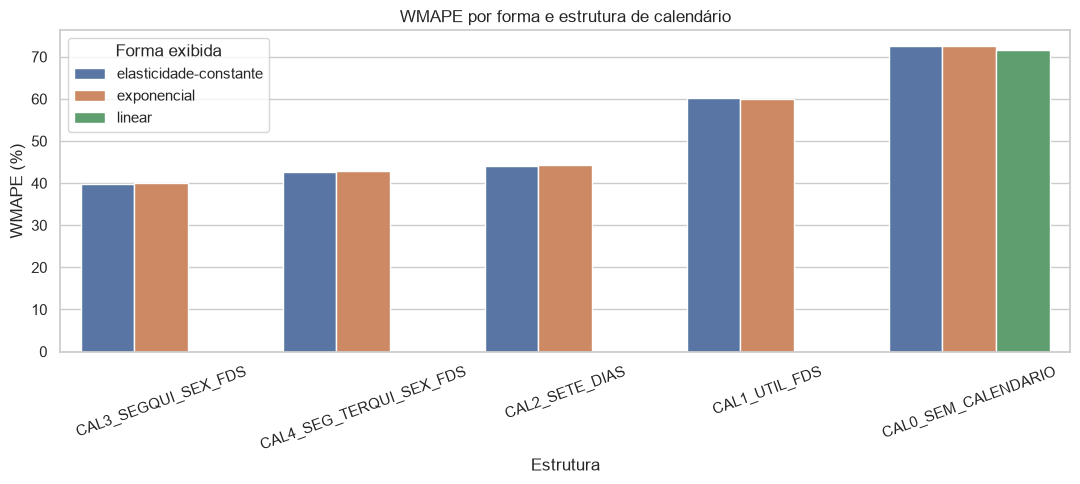

In [6]:
CALENDARIOS = {
    'CAL0_SEM_CALENDARIO': 'none',
    'CAL1_UTIL_FDS': 'weekend',
    'CAL2_SETE_DIAS': 'weekday',
    'CAL3_SEGQUI_SEX_FDS': 'grouped',
    'CAL4_SEG_TERQUI_SEX_FDS': 'grouped4',
}
FAMILIAS = {
    'linear': 'linear',
    'exponencial': 'exponential',
    'elasticidade-constante': 'power',
}

linhas_calendario = []
for rotulo_familia, family in FAMILIAS.items():
    for codigo_calendario, calendar in CALENDARIOS.items():
        codigo = f'{rotulo_familia} | {codigo_calendario}'
        specification = {'family': family, 'calendar': calendar}
        linha, _, _, _ = avaliar_especificacao(codigo, specification)
        linha['Forma exibida'] = rotulo_familia
        linha['Estrutura exibida'] = codigo_calendario
        linha['Válido para demanda'] = bool(
            linha['Previsões não positivas'] == 0
            and linha['Inclinação-base'] < 0
        )
        linhas_calendario.append(linha)

ranking_calendario = (
    pd.DataFrame(linhas_calendario)
    .set_index('Código')
    .sort_values(['Válido para demanda', 'WMAPE'], ascending=[False, True])
)
ranking_calendario.to_csv(TABLES_DIR / '02b_formas_e_calendarios.csv')

exibicao_calendario = ranking_calendario[[
    'Forma exibida', 'Estrutura exibida', 'Parâmetros', 'Válido para demanda',
    'Previsões não positivas', 'MAE', 'RMSE', 'MAPE', 'WMAPE', 'sMAPE',
    'BIC na escala de ajuste', 'AICc na escala de ajuste',
]].copy()
for coluna in ['MAPE', 'WMAPE', 'sMAPE']:
    exibicao_calendario[coluna] *= 100
display(exibicao_calendario.round(3))

validos = ranking_calendario.loc[ranking_calendario['Válido para demanda']].copy()
figura, eixo = plt.subplots(figsize=(11, 5))
grafico = validos.reset_index()
sns.barplot(
    data=grafico, x='Estrutura exibida', y=grafico['WMAPE'] * 100,
    hue='Forma exibida', ax=eixo,
)
eixo.set(
    title='WMAPE por forma e estrutura de calendário',
    xlabel='Estrutura', ylabel='WMAPE (%)',
)
eixo.tick_params(axis='x', rotation=20)
figura.tight_layout()
figura.savefig(FIGURES_DIR / '02b_formas_calendario.png', dpi=160, bbox_inches='tight')
plt.show()

**Resultado da rodada de calendário.** A combinação de elasticidade constante com `C3`
apresentou o menor WMAPE válido (`39,86%`), MAE de `11,20 kg` e RMSE de `18,52 kg`. A
exponencial com o mesmo calendário ficou praticamente empatada, com WMAPE de `40,07%`.
A linear passou a produzir volumes negativos em suas estruturas de calendário mais úteis e
não é apropriada para alimentar a otimização. Entre as duas curvas positivas quase
equivalentes, a potência é mantida porque teve erro ligeiramente menor, fornece elasticidade
diretamente e coincide com a forma \(A/P^B\) apresentada no documento da Minerva.

## 7. Terceira rodada: variáveis temporais incrementais

Com forma e calendário definidos, o processo *champion-challenger* testa as hipóteses
temporais levantadas no EDA: mês, quinzena, semana do mês e índice cronológico. O documento do
Desafio Minerva-Unifesp-ITA acrescenta a hipótese de maior demanda no início do mês, representada
pelos dias 1 a 7. A tendência também é combinada com esse indicador como desafio posterior.

O EDA mostrou que mês, quinzena e semana do mês possuem somente três ciclos e podem estar
confundidos com preço. Por isso, eles entram como challengers, não como variáveis previamente
aprovadas. Para evitar promover complexidade por ganho residual, candidatos com WMAPE até dois
pontos percentuais do melhor e RMSE até 5% do melhor formam uma zona de desempenho equivalente;
dentro dela, vence a especificação com menos parâmetros, apoiada por AICc e BIC.

Nesta rodada, `BASE_CALENDARIO` significa a curva já escolhida com preço e calendário, mas sem nova
variável temporal. O prefixo `ADD_` identifica exatamente a variável acrescentada a essa base. Logo,
o código informa a função do candidato e não apenas sua posição em uma sequência.


,Início do mês,Tendência,Mês,Quinzena,Semana do mês,Parâmetros,Zona equivalente,MAE,RMSE,MAPE,WMAPE,sMAPE,Viés (%),BIC na escala de ajuste,AICc na escala de ajuste,Previsão mínima
Código,,,,,,,,,,,,,,,,
ADD_SEMANA_MES,False,False,False,False,True,8,True,9.973,16.558,87.185,35.491,45.825,-24.645,87.521,75.260,1.109
ADD_INICIO_MES,True,False,False,False,False,5,True,10.350,16.820,90.006,36.833,48.194,-25.352,76.679,68.227,1.194
BASE_CALENDARIO,False,False,False,False,False,4,False,11.200,18.516,85.130,39.858,49.830,-29.933,75.712,68.759,1.191
ADD_QUINZENA,False,False,False,True,False,5,False,11.442,18.648,88.346,40.718,50.936,-28.872,78.604,70.152,1.211
ADD_INICIO_MES_TENDENCIA,True,True,False,False,False,6,False,12.969,20.793,81.439,46.153,55.341,-39.164,79.392,69.551,1.083
ADD_TENDENCIA,False,True,False,False,False,5,False,13.953,22.296,78.921,49.655,58.623,-42.887,78.467,70.015,1.079
ADD_MES,False,False,True,False,False,6,False,14.316,22.705,76.616,50.948,59.681,-45.087,81.758,71.918,0.992


p-valor HC3 de início do mês: 0.1622
Candidato selecionado pela regra de equivalência: ADD_INICIO_MES


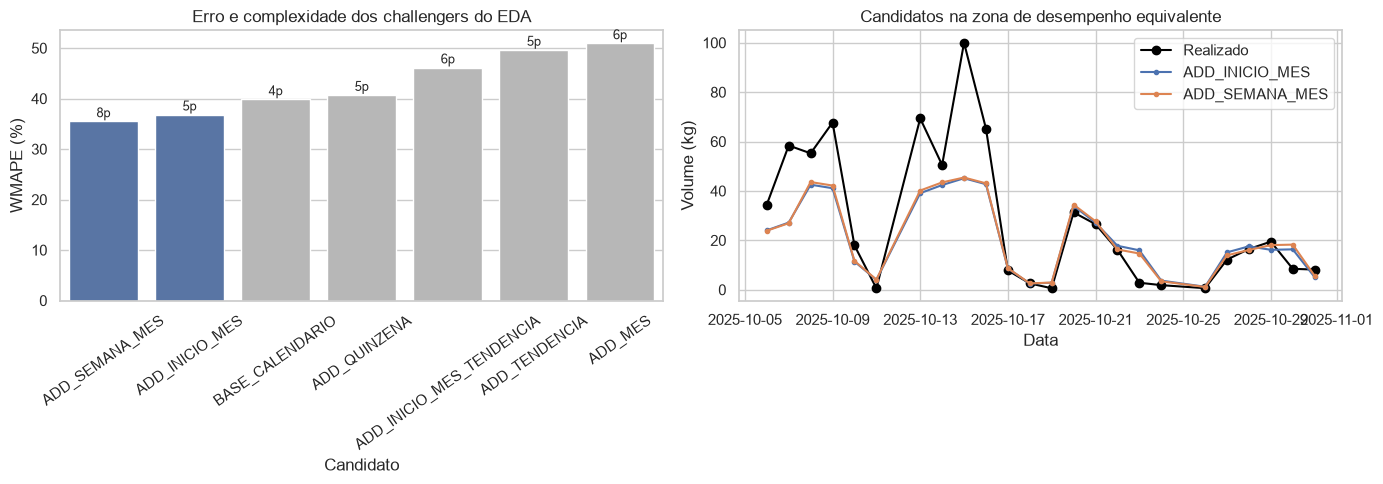

In [7]:
INCREMENTAIS = {
    'BASE_CALENDARIO': {
        'family': 'power', 'calendar': 'grouped',
    },
    'ADD_INICIO_MES': {
        'family': 'power', 'calendar': 'grouped', 'start_month': True,
    },
    'ADD_TENDENCIA': {
        'family': 'power', 'calendar': 'grouped', 'trend': True,
    },
    'ADD_MES': {
        'family': 'power', 'calendar': 'grouped', 'month': True,
    },
    'ADD_QUINZENA': {
        'family': 'power', 'calendar': 'grouped', 'fortnight': True,
    },
    'ADD_SEMANA_MES': {
        'family': 'power', 'calendar': 'grouped', 'week_of_month': True,
    },
    'ADD_INICIO_MES_TENDENCIA': {
        'family': 'power', 'calendar': 'grouped',
        'start_month': True, 'trend': True,
    },
}

linhas_incrementais = []
previsoes_incrementais = {}
for codigo, specification in INCREMENTAIS.items():
    linha, previsto, _, _ = avaliar_especificacao(codigo, specification)
    linhas_incrementais.append(linha)
    previsoes_incrementais[codigo] = previsto

ranking_incremental = (
    pd.DataFrame(linhas_incrementais).set_index('Código').sort_values('WMAPE')
)
melhor_wmape = float(ranking_incremental['WMAPE'].min())
melhor_rmse = float(ranking_incremental['RMSE'].min())
ranking_incremental['Zona equivalente'] = (
    (ranking_incremental['WMAPE'] <= melhor_wmape + 0.02)
    & (ranking_incremental['RMSE'] <= melhor_rmse * 1.05)
)
vencedor_incremental = str(
    ranking_incremental.loc[ranking_incremental['Zona equivalente']]
    .sort_values(['Parâmetros', 'AICc na escala de ajuste', 'WMAPE'])
    .index[0]
)
ranking_incremental.to_csv(TABLES_DIR / '02b_variaveis_incrementais.csv')

exibicao_incremental = ranking_incremental[[
    'Início do mês', 'Tendência', 'Mês', 'Quinzena', 'Semana do mês',
    'Parâmetros', 'Zona equivalente', 'MAE', 'RMSE', 'MAPE', 'WMAPE',
    'sMAPE', 'Viés (%)', 'BIC na escala de ajuste',
    'AICc na escala de ajuste', 'Previsão mínima',
]].copy()
for coluna in ['MAPE', 'WMAPE', 'sMAPE', 'Viés (%)']:
    exibicao_incremental[coluna] *= 100
display(exibicao_incremental.round(3))

modelo_m1_hc3, _ = ajustar_modelo(ajuste, INCREMENTAIS['ADD_INICIO_MES'], robust=True)
print(f"p-valor HC3 de início do mês: {modelo_m1_hc3.pvalues['inicio_mes']:.4f}")
print(f'Candidato selecionado pela regra de equivalência: {vencedor_incremental}')

figura, eixos = plt.subplots(1, 2, figsize=(14, 5))
ordem_grafico = ranking_incremental.sort_values('WMAPE').index
sns.barplot(
    x=ordem_grafico,
    y=100 * ranking_incremental.loc[ordem_grafico, 'WMAPE'],
    hue=ranking_incremental.loc[ordem_grafico, 'Zona equivalente'],
    palette={True: '#4c72b0', False: '#b7b7b7'},
    legend=False,
    ax=eixos[0],
)
for posicao, codigo in enumerate(ordem_grafico):
    parametros = int(ranking_incremental.loc[codigo, 'Parâmetros'])
    valor = 100 * ranking_incremental.loc[codigo, 'WMAPE']
    eixos[0].text(posicao, valor + 0.8, f'{parametros}p', ha='center', fontsize=9)
eixos[0].set(
    title='Erro e complexidade dos challengers do EDA',
    xlabel='Candidato', ylabel='WMAPE (%)',
)
eixos[0].tick_params(axis='x', rotation=35)

eixos[1].plot(
    validacao['data'], validacao['volume_kg'], marker='o',
    color='black', label='Realizado',
)
for codigo, cor in [('ADD_INICIO_MES', '#4c72b0'), ('ADD_SEMANA_MES', '#dd8452')]:
    eixos[1].plot(
        validacao['data'], previsoes_incrementais[codigo], marker='.',
        color=cor, label=codigo,
    )
eixos[1].set(
    title='Candidatos na zona de desempenho equivalente',
    xlabel='Data', ylabel='Volume (kg)',
)
eixos[1].legend()
figura.tight_layout()
figura.savefig(FIGURES_DIR / '02b_variaveis_incrementais.png', dpi=160, bbox_inches='tight')
plt.show()

**Resultado do corte único.** As variáveis formuladas no EDA foram efetivamente desafiadas.
`ADD_SEMANA_MES` obteve o menor WMAPE bruto (`35,49%`), enquanto `ADD_INICIO_MES` obteve
`36,83%`. A diferença foi de apenas `1,34` ponto percentual e o RMSE diferiu em cerca de `1,6%`,
colocando ambos na zona de desempenho equivalente. `ADD_SEMANA_MES` exige oito parâmetros e elevou
o BIC de `76,68` para `87,52` e o AICc de `68,23` para `75,26` em relação a
`ADD_INICIO_MES`.

Esse resultado é apenas provisório porque depende de um único corte temporal. O passo seguinte
repete a comparação em três janelas expansivas. A variável adicional somente será promovida se o
ganho persistir fora da amostra ao longo das janelas, e não apenas no período de outubro.


## 7.1 Validação temporal em janelas expansivas

É possível fazer K-fold sem aleatoriedade, mas, em séries temporais, o nome mais preciso é
**validação temporal por encadeamento para frente** (*forward chaining*) ou `TimeSeriesSplit`.
Cada fold treina exclusivamente no passado e valida no bloco imediatamente seguinte; nenhum dado
futuro retorna ao treinamento de uma janela anterior.

As 14 semanas de desenvolvimento permitem três validações não sobrepostas, com aproximadamente duas
semanas em cada bloco:

| Fold | Semanas de treino | Observações de treino | Semanas de validação | Observações de validação |
|---|---:|---:|---:|---:|
| 1 | 8 | 39 | 2 | 13 |
| 2 | 10 | 52 | 2 | 13 |
| 3 | 12 | 65 | 2 | 11 |

O primeiro fold, com 39 observações, fica ligeiramente abaixo da referência de 40 observações citada
por Phillips para uma curva somente de preço; por isso, ele funciona também como teste de estresse.
A regra é definida antes da tabela: minimizar o WMAPE médio de validação; considerar equivalentes os
modelos até dois pontos percentuais do melhor; dentro dessa zona, preferir menos parâmetros, menor
*gap* médio entre validação e treino e menor pior WMAPE. O holdout oficial permanece fora dos folds.


,Parâmetros,WMAPE_médio_treino,WMAPE_médio_validação,Gap_médio_WMAPE,Desvio_WMAPE_validação,Pior_WMAPE,Melhor_WMAPE,Elasticidade_mínima,Elasticidade_máxima,Zona equivalente,Elasticidade sempre negativa
Código,,,,,,,,,,,
BASE_CALENDARIO,4,29.521,40.218,10.697,9.114,47.056,29.871,-10.876,-6.640,True,True
ADD_INICIO_MES,5,29.202,41.367,12.166,8.278,50.404,34.149,-10.852,-6.261,True,True
ADD_QUINZENA,5,30.507,45.745,15.238,13.845,60.285,32.720,-11.241,-6.399,False,True
ADD_MES,6,29.435,48.876,19.441,6.680,56.202,43.122,-8.970,-6.897,False,True
ADD_INICIO_MES_TENDENCIA,6,28.838,53.339,24.501,16.935,71.283,37.637,-10.654,-7.927,False,True
ADD_SEMANA_MES,8,29.100,58.155,29.055,41.254,105.540,30.232,-10.624,-4.189,False,True
ADD_TENDENCIA,5,28.715,61.762,33.046,30.060,94.735,35.885,-11.651,-6.736,False,True
MIN_PRECO_LOGLOG,2,54.227,72.053,17.825,19.934,89.123,50.145,-7.640,-3.209,False,True


Candidato de nível selecionado pelas janelas: BASE_CALENDARIO


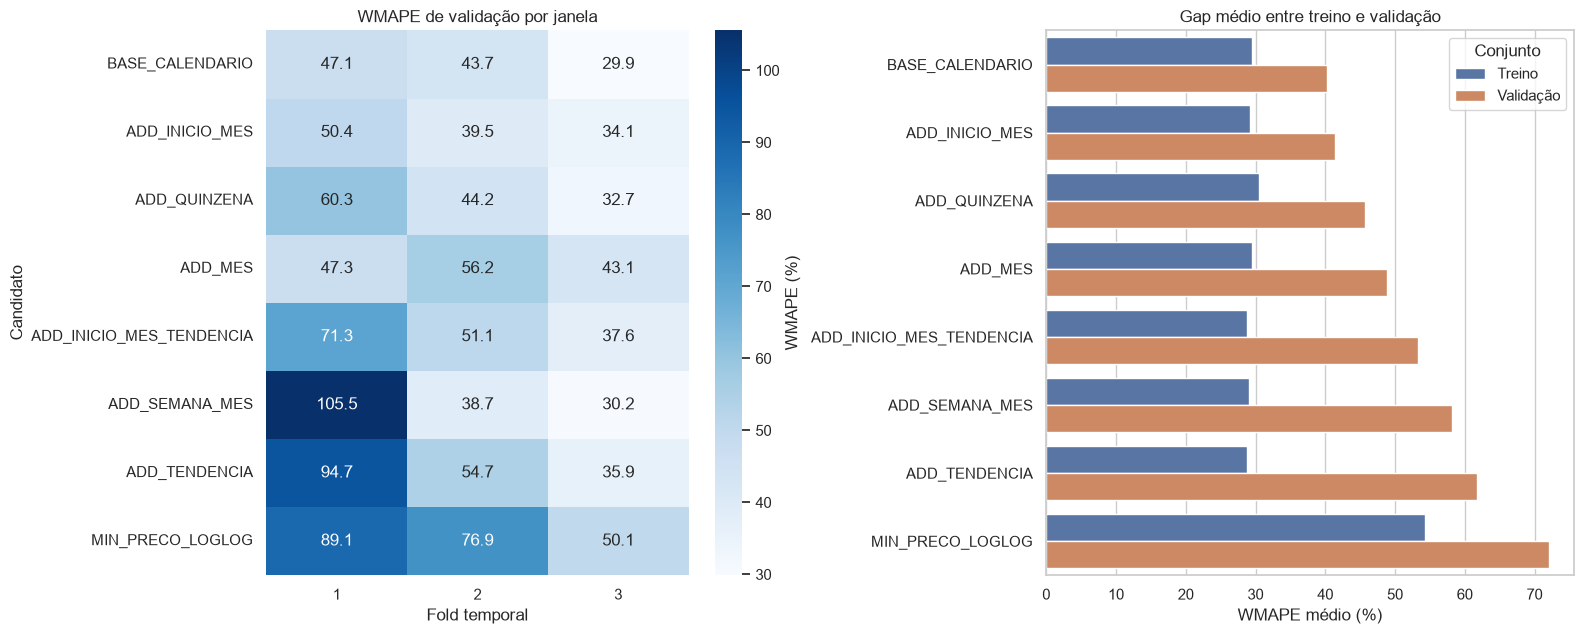

In [8]:
SEMANAS_DESENVOLVIMENTO = list(dados['inicio_semana'].drop_duplicates())
JANELAS_EXPANSIVAS = [
    {'fold': 1, 'fim_treino': 8, 'fim_validacao': 10},
    {'fold': 2, 'fim_treino': 10, 'fim_validacao': 12},
    {'fold': 3, 'fim_treino': 12, 'fim_validacao': 14},
]

CANDIDATOS_JANELAS = {
    'MIN_PRECO_LOGLOG': FORMAS['MIN_PRECO_LOGLOG'],
    **INCREMENTAIS,
}

def avaliar_janelas_temporais(especificacoes):
    linhas = []
    for janela in JANELAS_EXPANSIVAS:
        semanas_treino = SEMANAS_DESENVOLVIMENTO[:janela['fim_treino']]
        semanas_validacao = SEMANAS_DESENVOLVIMENTO[
            janela['fim_treino']:janela['fim_validacao']
        ]
        treino_fold = dados.loc[dados['inicio_semana'].isin(semanas_treino)].copy()
        validacao_fold = dados.loc[
            dados['inicio_semana'].isin(semanas_validacao)
        ].copy()
        for codigo, specification in especificacoes.items():
            modelo, smearing = ajustar_modelo(treino_fold, specification)
            previsao_treino = prever_modelo(
                modelo, smearing, treino_fold, specification
            )
            previsao_validacao = prever_modelo(
                modelo, smearing, validacao_fold, specification
            )
            metricas_treino = calcular_metricas(
                treino_fold['volume_kg'], previsao_treino
            )
            metricas_validacao = calcular_metricas(
                validacao_fold['volume_kg'], previsao_validacao
            )
            linhas.append({
                'Fold': janela['fold'],
                'Código': codigo,
                'Treino início': treino_fold['data'].min().date(),
                'Treino fim': treino_fold['data'].max().date(),
                'Validação início': validacao_fold['data'].min().date(),
                'Validação fim': validacao_fold['data'].max().date(),
                'N treino': len(treino_fold),
                'N validação': len(validacao_fold),
                'Parâmetros': len(modelo.params),
                'WMAPE treino': metricas_treino['WMAPE'],
                'WMAPE validação': metricas_validacao['WMAPE'],
                'Gap WMAPE': metricas_validacao['WMAPE'] - metricas_treino['WMAPE'],
                'MAE validação': metricas_validacao['MAE'],
                'RMSE validação': metricas_validacao['RMSE'],
                'Elasticidade-base': float(modelo.params['ln_preco']),
            })
    return pd.DataFrame(linhas)

def resumir_janelas_temporais(detalhes):
    return (
        detalhes.groupby('Código')
        .agg(
            Parâmetros=('Parâmetros', 'max'),
            WMAPE_médio_treino=('WMAPE treino', 'mean'),
            WMAPE_médio_validação=('WMAPE validação', 'mean'),
            Gap_médio_WMAPE=('Gap WMAPE', 'mean'),
            Desvio_WMAPE_validação=('WMAPE validação', 'std'),
            Pior_WMAPE=('WMAPE validação', 'max'),
            Melhor_WMAPE=('WMAPE validação', 'min'),
            Elasticidade_mínima=('Elasticidade-base', 'min'),
            Elasticidade_máxima=('Elasticidade-base', 'max'),
        )
        .sort_values('WMAPE_médio_validação')
    )

detalhe_janelas = avaliar_janelas_temporais(CANDIDATOS_JANELAS)
resumo_janelas = resumir_janelas_temporais(detalhe_janelas)
melhor_wmape_janelas = float(resumo_janelas['WMAPE_médio_validação'].min())
resumo_janelas['Zona equivalente'] = (
    resumo_janelas['WMAPE_médio_validação'] <= melhor_wmape_janelas + 0.02
)
resumo_janelas['Elasticidade sempre negativa'] = (
    resumo_janelas['Elasticidade_máxima'] < 0
)
vencedor_janelas = str(
    resumo_janelas.loc[resumo_janelas['Zona equivalente']]
    .sort_values([
        'Parâmetros', 'Gap_médio_WMAPE',
        'Pior_WMAPE', 'WMAPE_médio_validação',
    ])
    .index[0]
)
ESPECIFICACAO_NIVEL = CANDIDATOS_JANELAS[vencedor_janelas].copy()

detalhe_janelas.to_csv(
    TABLES_DIR / '02b_validacao_temporal_folds.csv', index=False
)
resumo_janelas.to_csv(TABLES_DIR / '02b_validacao_temporal_resumo.csv')

exibicao_janelas = resumo_janelas.copy()
colunas_percentuais = [
    'WMAPE_médio_treino', 'WMAPE_médio_validação', 'Gap_médio_WMAPE',
    'Desvio_WMAPE_validação', 'Pior_WMAPE', 'Melhor_WMAPE',
]
exibicao_janelas[colunas_percentuais] *= 100
display(exibicao_janelas.round(3))
print(f'Candidato de nível selecionado pelas janelas: {vencedor_janelas}')

figura, eixos = plt.subplots(1, 2, figsize=(16, 6.5))
matriz_wmape = (
    detalhe_janelas.pivot(index='Código', columns='Fold', values='WMAPE validação')
    .loc[resumo_janelas.index]
    * 100
)
sns.heatmap(
    matriz_wmape, annot=True, fmt='.1f', cmap='Blues',
    cbar_kws={'label': 'WMAPE (%)'}, ax=eixos[0],
)
eixos[0].set(
    title='WMAPE de validação por janela', xlabel='Fold temporal', ylabel='Candidato',
)

ordem = resumo_janelas.index
comparacao_gap = (
    resumo_janelas.loc[ordem, ['WMAPE_médio_treino', 'WMAPE_médio_validação']]
    .rename(columns={
        'WMAPE_médio_treino': 'Treino',
        'WMAPE_médio_validação': 'Validação',
    })
    .mul(100)
    .reset_index()
    .melt(id_vars='Código', var_name='Conjunto', value_name='WMAPE (%)')
)
sns.barplot(
    data=comparacao_gap, y='Código', x='WMAPE (%)', hue='Conjunto',
    order=ordem, ax=eixos[1],
)
eixos[1].set(
    title='Gap médio entre treino e validação',
    xlabel='WMAPE médio (%)', ylabel='',
)
figura.tight_layout()
figura.savefig(
    FIGURES_DIR / '02b_validacao_temporal_janelas.png',
    dpi=160, bbox_inches='tight',
)
plt.show()


**Resultado das janelas temporais.** `BASE_CALENDARIO` apresentou o menor WMAPE médio de
validação (`40,22%`), *gap* médio de `10,70` pontos percentuais e pior janela de `47,06%`.
`ADD_INICIO_MES` ficou na zona equivalente, com WMAPE médio de `41,37%`, *gap* de `12,17`
pontos e pior janela de `50,40%`, mas utiliza um parâmetro adicional. Portanto, o efeito de início
do mês observado no corte único não é promovido.

O diagnóstico mais claro de sobreajuste aparece em `ADD_SEMANA_MES`: apesar de vencer no corte de
outubro, seu WMAPE médio nas janelas sobe para `58,16%`, o *gap* médio chega a `29,06` pontos e a
pior janela atinge `105,54%`. `ADD_TENDENCIA` também é instável, com WMAPE médio de `61,76%`.
Todas as elasticidades-base permaneceram negativas. A seleção de variáveis passa, assim, de
`ADD_INICIO_MES` para `BASE_CALENDARIO`.


## 8. Quarta rodada: elasticidade compartilhada ou por contexto

A rodada de elasticidade é agora condicionada ao vencedor das janelas expansivas,
`BASE_CALENDARIO`. A especificação compartilhada permite níveis de demanda diferentes sem supor
respostas distintas ao preço. O challenger acrescenta as interações `ln(preço) × sexta` e
`ln(preço) × fim de semana`. A maior complexidade só será aceita se melhorar tanto o corte único
quanto a média das três janelas, mantiver demandas positivas e produzir inclinações economicamente
coerentes.

Os nomes registram a hipótese: `ELAST_COMPARTILHADA` mantém uma única inclinação de preço e
`ELAST_POR_CONTEXTO` adiciona inclinações para sexta e fim de semana.


,Parâmetros,Elasticidade segunda–quinta,Elasticidade sexta,Elasticidade fim de semana,MAE,RMSE,MAPE,WMAPE,sMAPE,BIC na escala de ajuste,AICc na escala de ajuste,p-valor conjunto interações
Código,,,,,,,,,,,,
ELAST_COMPARTILHADA,4,-8.0662,-8.0662,-8.0662,11.2001,18.5160,85.1302,39.8583,49.8301,75.7125,68.7586,NaN
ELAST_POR_CONTEXTO,6,-5.6656,-12.0951,-11.1439,12.9005,20.7955,96.9412,45.9096,53.9016,82.7086,72.8678,0.7903


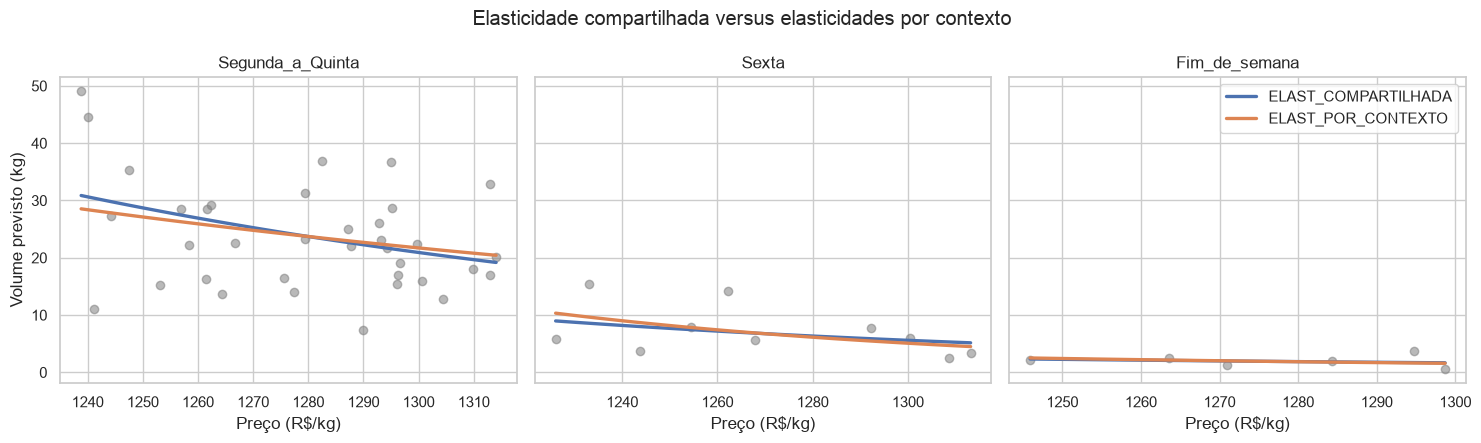

,Parâmetros,WMAPE_médio_treino,WMAPE_médio_validação,Gap_médio_WMAPE,Desvio_WMAPE_validação,Pior_WMAPE,Melhor_WMAPE,Elasticidade_mínima,Elasticidade_máxima
Código,,,,,,,,,
ELAST_COMPARTILHADA,4,29.521,40.218,10.697,9.114,47.056,29.871,-10.876,-6.640
ELAST_POR_CONTEXTO,6,28.862,44.344,15.482,12.114,52.965,30.493,-14.656,-3.194


In [9]:
ELASTICIDADES = {
    'ELAST_COMPARTILHADA': {
        **ESPECIFICACAO_NIVEL, 'interaction': False,
    },
    'ELAST_POR_CONTEXTO': {
        **ESPECIFICACAO_NIVEL, 'interaction': True,
    },
}


linhas_elasticidade = []
modelos_elasticidade = {}
smearings_elasticidade = {}
for codigo, specification in ELASTICIDADES.items():
    linha, _, modelo, smearing = avaliar_especificacao(codigo, specification)
    modelos_elasticidade[codigo] = modelo
    smearings_elasticidade[codigo] = smearing
    if specification['interaction']:
        elasticidade_base = float(modelo.params['ln_preco'])
        linha['Elasticidade segunda–quinta'] = elasticidade_base
        linha['Elasticidade sexta'] = float(
            elasticidade_base + modelo.params['ln_preco_x_Sexta']
        )
        linha['Elasticidade fim de semana'] = float(
            elasticidade_base + modelo.params['ln_preco_x_Fim_de_semana']
        )
    else:
        elasticidade_base = float(modelo.params['ln_preco'])
        linha['Elasticidade segunda–quinta'] = elasticidade_base
        linha['Elasticidade sexta'] = elasticidade_base
        linha['Elasticidade fim de semana'] = elasticidade_base
    linhas_elasticidade.append(linha)

ranking_elasticidade = (
    pd.DataFrame(linhas_elasticidade).set_index('Código').sort_values('WMAPE')
)

modelo_s1_hc3, _ = ajustar_modelo(
    ajuste, ELASTICIDADES['ELAST_POR_CONTEXTO'], robust=True
)
nomes_s1 = list(modelo_s1_hc3.params.index)
restricoes = np.zeros((2, len(nomes_s1)))
restricoes[0, nomes_s1.index('ln_preco_x_Sexta')] = 1
restricoes[1, nomes_s1.index('ln_preco_x_Fim_de_semana')] = 1
teste_interacoes = modelo_s1_hc3.wald_test(restricoes, scalar=True)
ranking_elasticidade['p-valor conjunto interações'] = np.nan
ranking_elasticidade.loc[
    'ELAST_POR_CONTEXTO', 'p-valor conjunto interações'
] = float(teste_interacoes.pvalue)
ranking_elasticidade.to_csv(TABLES_DIR / '02b_elasticidade_compartilhada_variada.csv')

exibicao_elasticidade = ranking_elasticidade[[
    'Parâmetros', 'Elasticidade segunda–quinta', 'Elasticidade sexta',
    'Elasticidade fim de semana', 'MAE', 'RMSE', 'MAPE', 'WMAPE',
    'sMAPE', 'BIC na escala de ajuste', 'AICc na escala de ajuste',
    'p-valor conjunto interações',
]].copy()
for coluna in ['MAPE', 'WMAPE', 'sMAPE']:
    exibicao_elasticidade[coluna] *= 100
display(exibicao_elasticidade.round(4))

dias_representativos = {
    'Segunda_a_Quinta': 'Segunda', 'Sexta': 'Sexta', 'Fim_de_semana': 'Sábado'
}
contexto_ajuste = ajuste['dia_semana'].map(MAPAS_CONTEXTO['grouped'])
figura, eixos = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
for eixo, contexto in zip(eixos, ORDEM_CONTEXTO['grouped']):
    recorte = ajuste.loc[contexto_ajuste == contexto]
    grade = np.linspace(recorte['preco_kg'].min(), recorte['preco_kg'].max(), 100)
    base_grade = pd.DataFrame({
        'preco_kg': grade,
        'dia_semana': dias_representativos[contexto],
        'inicio_mes': 0,
        'indice_tempo': 0,
    })
    eixo.scatter(recorte['preco_kg'], recorte['volume_kg'], alpha=0.55, color='gray')
    for codigo, cor in [('ELAST_COMPARTILHADA', '#4c72b0'), ('ELAST_POR_CONTEXTO', '#dd8452')]:
        previsto = prever_modelo(
            modelos_elasticidade[codigo], smearings_elasticidade[codigo],
            base_grade, ELASTICIDADES[codigo],
        )
        eixo.plot(grade, previsto, color=cor, linewidth=2.4, label=codigo)
    eixo.set(title=contexto, xlabel='Preço (R$/kg)')
eixos[0].set_ylabel('Volume previsto (kg)')
eixos[-1].legend()
figura.suptitle('Elasticidade compartilhada versus elasticidades por contexto')
figura.tight_layout()
figura.savefig(FIGURES_DIR / '02b_elasticidades_contexto.png', dpi=160, bbox_inches='tight')
plt.show()


detalhe_elasticidade_janelas = avaliar_janelas_temporais(ELASTICIDADES)
resumo_elasticidade_janelas = resumir_janelas_temporais(
    detalhe_elasticidade_janelas
)
detalhe_elasticidade_janelas.to_csv(
    TABLES_DIR / '02b_elasticidade_folds.csv', index=False
)
resumo_elasticidade_janelas.to_csv(
    TABLES_DIR / '02b_elasticidade_folds_resumo.csv'
)
exibicao_elasticidade_janelas = resumo_elasticidade_janelas.copy()
for coluna in [
    'WMAPE_médio_treino', 'WMAPE_médio_validação', 'Gap_médio_WMAPE',
    'Desvio_WMAPE_validação', 'Pior_WMAPE', 'Melhor_WMAPE',
]:
    exibicao_elasticidade_janelas[coluna] *= 100
display(exibicao_elasticidade_janelas.round(3))


**Resultado das elasticidades.** No corte único, `ELAST_COMPARTILHADA` obteve WMAPE de
`39,86%`, contra `45,91%` de `ELAST_POR_CONTEXTO`, além de menor RMSE, BIC e AICc. O teste conjunto
das interações apresentou `p = 0,7903`.

As janelas confirmam a decisão: a inclinação compartilhada teve WMAPE médio de `40,22%`, *gap* de
`10,70` pontos e pior janela de `47,06%`; as inclinações por contexto tiveram `44,34%`, *gap* de
`15,48` pontos e pior janela de `52,96%`. O challenger melhora ligeiramente o ajuste médio de treino,
mas piora fora da amostra — padrão compatível com sobreajuste. A elasticidade compartilhada é mantida.


## 9. Decisão antes do ajuste final

A seleção termina antes da leitura do holdout nesta execução. O campeão combina a forma de potência
indicada pelo documento da Minerva, calendário parcimonioso e uma única elasticidade. Nenhuma
variável temporal adicional permaneceu após as três janelas. Esta célula resume as decisões para que
o ajuste final não altere silenciosamente a especificação.


,Decisão,Escolha,Critério
0,Forma funcional,Elasticidade constante,Curva positiva com elasticidade interpretável
1,Calendário,Segunda–quinta / sexta / fim de semana,Melhor WMAPE médio nas três janelas
2,Variáveis adicionais,Nenhuma,Ganhos do corte único não persistiram nas janelas
3,Início do mês,Excluído,Um parâmetro adicional sem melhora temporal es...
4,Elasticidade,Compartilhada,"Menor erro, gap e complexidade que ELAST_POR_C..."
5,Holdout,Ainda não acessado,Reservado para avaliação final


,Etapa,Código,O que o modelo faz,Origem da hipótese,Parâmetros,WMAPE corte único (%),WMAPE médio janelas (%),Gap médio WMAPE (p.p.),Pior WMAPE (%),BIC,Decisão
0,1. Modelo mínimo,MIN_PRECO_LOGLOG,Explica volume somente por log(preço),Phillips 4.2.1,2,72.62,72.05,17.83,89.12,153.10,Referência inicial
1,2. Calendário-base,BASE_CALENDARIO,Adiciona níveis para sexta e fim de semana,EDA + documento da Minerva,4,39.86,40.22,10.70,47.06,75.71,Promovido
2,3. Início do mês,ADD_INICIO_MES,Adiciona indicador para os dias 1 a 7,Documento da Minerva,5,36.83,41.37,12.17,50.40,76.68,Rejeitado nas janelas
3,4. Semana do mês,ADD_SEMANA_MES,Adiciona quatro indicadores de semana,EDA,8,35.49,58.16,29.06,105.54,87.52,Rejeitado por instabilidade
4,5. Inclinações por contexto,ELAST_POR_CONTEXTO,Permite elasticidades distintas por contexto,Phillips 4.3.3 + EDA,6,45.91,44.34,15.48,52.96,82.71,Rejeitado
5,6. Modelo final,ELAST_COMPARTILHADA,Mantém calendário e uma elasticidade comum,Validação temporal,4,39.86,40.22,10.70,47.06,75.71,Campeão congelado


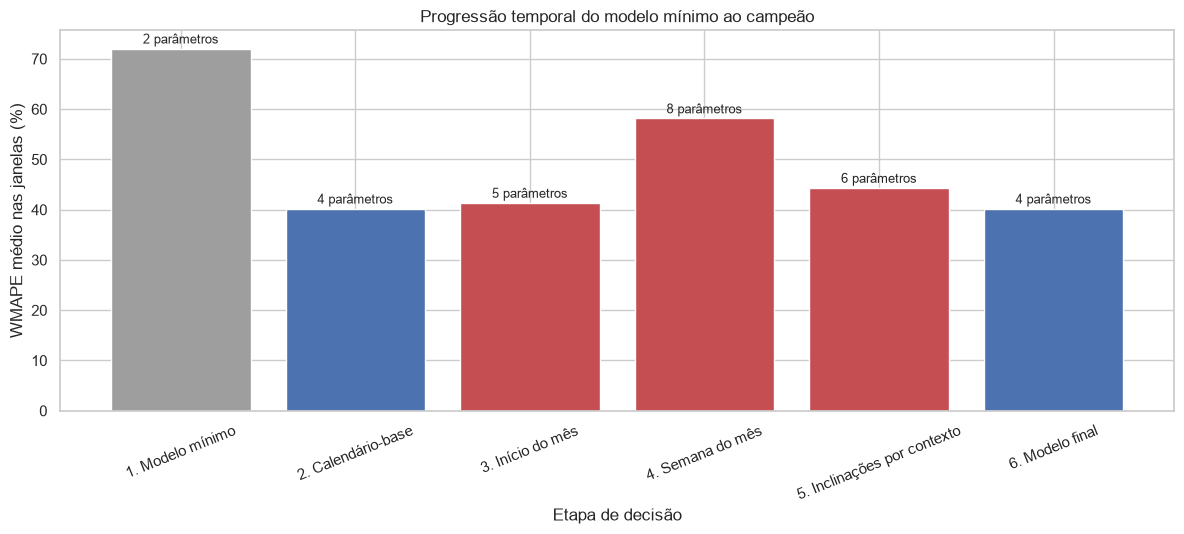

In [10]:
ESPECIFICACAO_CAMPEA = ELASTICIDADES['ELAST_COMPARTILHADA']
resumo_decisoes = pd.DataFrame([
    ('Forma funcional', 'Elasticidade constante', 'Curva positiva com elasticidade interpretável'),
    ('Calendário', 'Segunda–quinta / sexta / fim de semana', 'Melhor WMAPE médio nas três janelas'),
    ('Variáveis adicionais', 'Nenhuma', 'Ganhos do corte único não persistiram nas janelas'),
    ('Início do mês', 'Excluído', 'Um parâmetro adicional sem melhora temporal estável'),
    ('Elasticidade', 'Compartilhada', 'Menor erro, gap e complexidade que ELAST_POR_CONTEXTO'),
    ('Holdout', 'Ainda não acessado', 'Reservado para avaliação final'),
], columns=['Decisão', 'Escolha', 'Critério'])
display(resumo_decisoes)

def linha_progressao(
    etapa, codigo, alteracao, origem, tabela_pontual, codigo_pontual,
    tabela_janelas, codigo_janelas, status,
):
    pontual = tabela_pontual.loc[codigo_pontual]
    temporal = tabela_janelas.loc[codigo_janelas]
    return {
        'Etapa': etapa,
        'Código': codigo,
        'O que o modelo faz': alteracao,
        'Origem da hipótese': origem,
        'Parâmetros': int(pontual['Parâmetros']),
        'WMAPE corte único (%)': 100 * float(pontual['WMAPE']),
        'WMAPE médio janelas (%)': 100 * float(temporal['WMAPE_médio_validação']),
        'Gap médio WMAPE (p.p.)': 100 * float(temporal['Gap_médio_WMAPE']),
        'Pior WMAPE (%)': 100 * float(temporal['Pior_WMAPE']),
        'BIC': float(pontual['BIC na escala de ajuste']),
        'Decisão': status,
    }

progressao_modelo = pd.DataFrame([
    linha_progressao(
        '1. Modelo mínimo', 'MIN_PRECO_LOGLOG',
        'Explica volume somente por log(preço)', 'Phillips 4.2.1',
        ranking_forma, 'MIN_PRECO_LOGLOG',
        resumo_janelas, 'MIN_PRECO_LOGLOG', 'Referência inicial',
    ),
    linha_progressao(
        '2. Calendário-base', 'BASE_CALENDARIO',
        'Adiciona níveis para sexta e fim de semana', 'EDA + documento da Minerva',
        ranking_incremental, 'BASE_CALENDARIO',
        resumo_janelas, 'BASE_CALENDARIO', 'Promovido',
    ),
    linha_progressao(
        '3. Início do mês', 'ADD_INICIO_MES',
        'Adiciona indicador para os dias 1 a 7', 'Documento da Minerva',
        ranking_incremental, 'ADD_INICIO_MES',
        resumo_janelas, 'ADD_INICIO_MES', 'Rejeitado nas janelas',
    ),
    linha_progressao(
        '4. Semana do mês', 'ADD_SEMANA_MES',
        'Adiciona quatro indicadores de semana', 'EDA',
        ranking_incremental, 'ADD_SEMANA_MES',
        resumo_janelas, 'ADD_SEMANA_MES', 'Rejeitado por instabilidade',
    ),
    linha_progressao(
        '5. Inclinações por contexto', 'ELAST_POR_CONTEXTO',
        'Permite elasticidades distintas por contexto', 'Phillips 4.3.3 + EDA',
        ranking_elasticidade, 'ELAST_POR_CONTEXTO',
        resumo_elasticidade_janelas, 'ELAST_POR_CONTEXTO', 'Rejeitado',
    ),
    linha_progressao(
        '6. Modelo final', 'ELAST_COMPARTILHADA',
        'Mantém calendário e uma elasticidade comum', 'Validação temporal',
        ranking_elasticidade, 'ELAST_COMPARTILHADA',
        resumo_elasticidade_janelas, 'ELAST_COMPARTILHADA', 'Campeão congelado',
    ),
])
progressao_modelo.to_csv(TABLES_DIR / '02b_progressao_modelo.csv', index=False)
display(progressao_modelo.round(2))

figura, eixo = plt.subplots(figsize=(12, 5.5))
cores = [
    '#9e9e9e' if decisao == 'Referência inicial'
    else '#c44e52' if decisao.startswith('Rejeitado')
    else '#4c72b0'
    for decisao in progressao_modelo['Decisão']
]
barras = eixo.bar(
    progressao_modelo['Etapa'],
    progressao_modelo['WMAPE médio janelas (%)'],
    color=cores,
)
for barra, parametros in zip(barras, progressao_modelo['Parâmetros']):
    eixo.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + 1,
        f'{parametros} parâmetros',
        ha='center', fontsize=9,
    )
eixo.set(
    title='Progressão temporal do modelo mínimo ao campeão',
    xlabel='Etapa de decisão', ylabel='WMAPE médio nas janelas (%)',
)
eixo.tick_params(axis='x', rotation=22)
figura.tight_layout()
figura.savefig(FIGURES_DIR / '02b_progressao_modelo.png', dpi=160, bbox_inches='tight')
plt.show()


**Resultado da seleção.** A fórmula congelada para reestimação é

\[
\log(Q_t)=\alpha+\beta\log(P_t)+\gamma_1 I(\text{sexta})
+\gamma_2 I(\text{fim de semana})+\varepsilon_t.
\]

A categoria de referência é segunda a quinta. A tabela de progressão mostra que o maior ganho vem do
calendário. `ADD_INICIO_MES` e `ADD_SEMANA_MES` pareciam úteis no corte único, mas não generalizaram
nas três janelas. Nenhuma variável adicional será escolhida após a leitura do holdout.


## 10. Ajuste final nas 76 observações

Conforme o processo do livro, o campeão é reestimado com todo o desenvolvimento depois de
encerrada a seleção. Erros-padrão HC3 são usados porque inferência convencional pode ser
sensível à heterocedasticidade. O fator de *smearing* é recalculado apenas nos 76 dias.

,Coeficiente,Erro padrão HC3,p-valor HC3,IC95 inferior,IC95 superior
const,91.59146,19.08530,0.0,54.18496,128.99796
ln_preco,-12.36470,2.66956,0.0,-17.59694,-7.13245
contexto_Sexta,-1.33944,0.15083,0.0,-1.63506,-1.04382
contexto_Fim_de_semana,-2.96701,0.29824,0.0,-3.55155,-2.38246


,Efeito,Variação de volume (%)
0,Sexta,-73.80
1,Fim de semana,-94.85


Fator de smearing: 1.122597


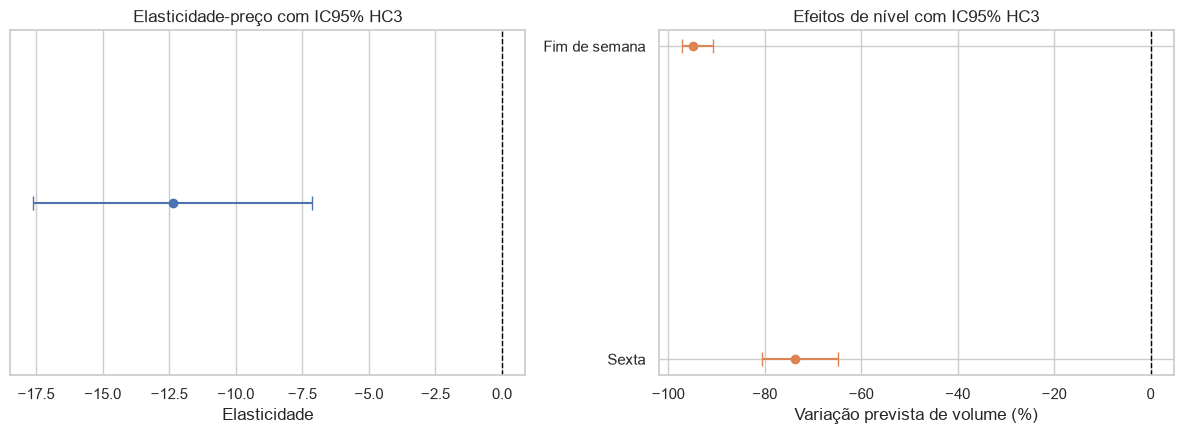

In [11]:
modelo_final_convencional, smearing_final = ajustar_modelo(
    dados, ESPECIFICACAO_CAMPEA, robust=False
)
modelo_final_hc3, _ = ajustar_modelo(
    dados, ESPECIFICACAO_CAMPEA, robust=True
)

intervalos = modelo_final_hc3.conf_int()
tabela_coeficientes = pd.DataFrame({
    'Coeficiente': modelo_final_hc3.params,
    'Erro padrão HC3': modelo_final_hc3.bse,
    'p-valor HC3': modelo_final_hc3.pvalues,
    'IC95 inferior': intervalos[0],
    'IC95 superior': intervalos[1],
})
tabela_coeficientes.to_csv(TABLES_DIR / '02b_coeficientes_finais.csv')
display(tabela_coeficientes.round(5))

efeitos_multiplicativos = pd.DataFrame({
    'Efeito': ['Sexta', 'Fim de semana'],
    'Variação de volume (%)': 100 * (
        np.exp([
            modelo_final_hc3.params['contexto_Sexta'],
            modelo_final_hc3.params['contexto_Fim_de_semana'],
        ]) - 1
    ),
})
display(efeitos_multiplicativos.round(2))
print(f'Fator de smearing: {smearing_final:.6f}')

figura, eixos = plt.subplots(1, 2, figsize=(12, 4.5))
elasticidade = float(modelo_final_hc3.params['ln_preco'])
elasticidade_inf = float(intervalos.loc['ln_preco', 0])
elasticidade_sup = float(intervalos.loc['ln_preco', 1])
eixos[0].errorbar(
    elasticidade, 0,
    xerr=[[elasticidade - elasticidade_inf], [elasticidade_sup - elasticidade]],
    fmt='o', color='#4c72b0', capsize=5,
)
eixos[0].axvline(0, color='black', linewidth=1, linestyle='--')
eixos[0].set(
    title='Elasticidade-preço com IC95% HC3', xlabel='Elasticidade', yticks=[],
)

nomes_efeitos = ['Sexta', 'Fim de semana']
coeficientes_efeitos = ['contexto_Sexta', 'contexto_Fim_de_semana']
efeitos = 100 * (np.exp(modelo_final_hc3.params[coeficientes_efeitos]) - 1)
efeitos_inf = 100 * (np.exp(intervalos.loc[coeficientes_efeitos, 0]) - 1)
efeitos_sup = 100 * (np.exp(intervalos.loc[coeficientes_efeitos, 1]) - 1)
eixos[1].errorbar(
    efeitos, nomes_efeitos,
    xerr=[efeitos - efeitos_inf, efeitos_sup - efeitos],
    fmt='o', color='#dd8452', capsize=5,
)
eixos[1].axvline(0, color='black', linewidth=1, linestyle='--')
eixos[1].set(
    title='Efeitos de nível com IC95% HC3', xlabel='Variação prevista de volume (%)',
)
figura.tight_layout()
figura.savefig(FIGURES_DIR / '02b_coeficientes_finais.png', dpi=160, bbox_inches='tight')
plt.show()


**Resultado do ajuste final.** A elasticidade compartilhada é aproximadamente `-12,36`,
com intervalo HC3 de 95% entre `-17,60` e `-7,13` e `p < 0,001`. Mantido preço constante, sexta e
fim de semana apresentam níveis previstos substancialmente menores que segunda–quinta. O modelo não
contém efeito de início do mês, porque esse ganho não persistiu nas janelas temporais. O fator de
retransformação é aproximadamente `1,1226`.


## 11. Diagnósticos de resíduos e influência

A curva será usada por um otimizador, portanto não basta informar erro médio. O teste de
Breusch–Pagan verifica variância não constante; Durbin–Watson e Ljung–Box examinam dependência
temporal; distância de Cook e *leave-one-out* mostram se poucos dias determinam a
elasticidade.

,Indicador,Resultado
0,Breusch–Pagan p-valor,0.01749
1,Durbin–Watson,1.82818
2,Ljung–Box p-valor (lag 5),0.94284
3,Cook > 4/n,5.00000
4,Alavancagem > 2p/n,7.00000
5,Elasticidade LOO mínima,-14.09939
6,Elasticidade LOO máxima,-11.19854
7,Maior deslocamento LOO,1.73469


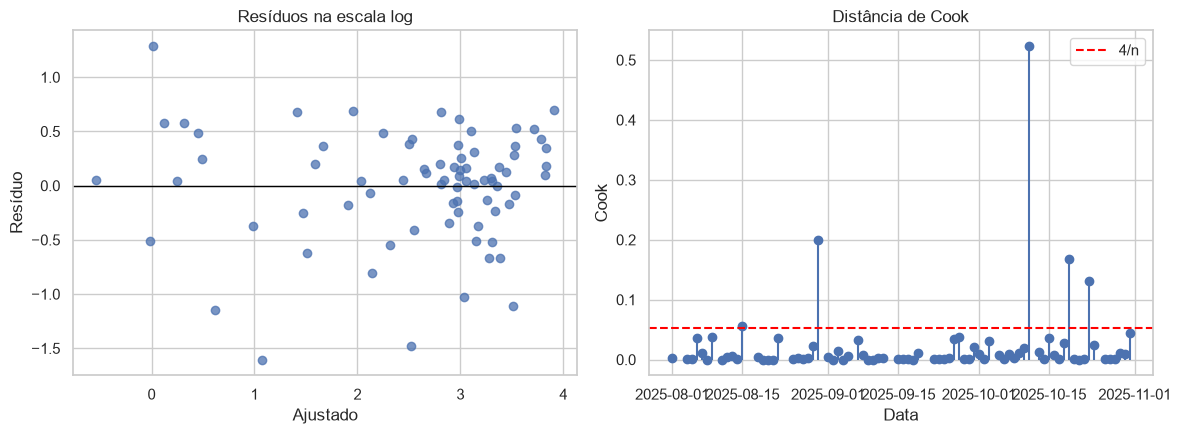

In [12]:
matriz_final = matriz_desenho(dados, ESPECIFICACAO_CAMPEA)
residuos = modelo_final_convencional.resid
bp_lm, bp_p, bp_f, bp_f_p = het_breuschpagan(residuos, matriz_final)
dw = float(durbin_watson(residuos))
ljung = acorr_ljungbox(residuos, lags=[5], return_df=True)

influencia = modelo_final_convencional.get_influence()
cooks = influencia.cooks_distance[0]
alavancagem = influencia.hat_matrix_diag
limite_cook = 4 / len(dados)
limite_alavancagem = 2 * matriz_final.shape[1] / len(dados)

elasticidades_loo = []
for indice in dados.index:
    base_loo = dados.drop(index=indice)
    modelo_loo, _ = ajustar_modelo(base_loo, ESPECIFICACAO_CAMPEA)
    elasticidades_loo.append(float(modelo_loo.params['ln_preco']))

diagnosticos = pd.DataFrame({
    'Indicador': [
        'Breusch–Pagan p-valor', 'Durbin–Watson', 'Ljung–Box p-valor (lag 5)',
        'Cook > 4/n', 'Alavancagem > 2p/n', 'Elasticidade LOO mínima',
        'Elasticidade LOO máxima', 'Maior deslocamento LOO',
    ],
    'Resultado': [
        bp_p, dw, float(ljung.loc[5, 'lb_pvalue']),
        int(np.sum(cooks > limite_cook)),
        int(np.sum(alavancagem > limite_alavancagem)),
        min(elasticidades_loo), max(elasticidades_loo),
        float(np.max(np.abs(np.asarray(elasticidades_loo) - modelo_final_hc3.params['ln_preco']))),
    ],
})
diagnosticos.to_csv(TABLES_DIR / '02b_diagnosticos.csv', index=False)
display(diagnosticos.round(5))

figura, eixos = plt.subplots(1, 2, figsize=(12, 4.5))
eixos[0].scatter(modelo_final_convencional.fittedvalues, residuos, alpha=0.75)
eixos[0].axhline(0, color='black', linewidth=1)
eixos[0].set(title='Resíduos na escala log', xlabel='Ajustado', ylabel='Resíduo')
eixos[1].stem(dados['data'], cooks, markerfmt='o', basefmt=' ')
eixos[1].axhline(limite_cook, color='red', linestyle='--', label='4/n')
eixos[1].set(title='Distância de Cook', xlabel='Data', ylabel='Cook')
eixos[1].legend()
figura.tight_layout()
figura.savefig(FIGURES_DIR / '02b_diagnosticos_influencia.png', dpi=160, bbox_inches='tight')
plt.show()

**Resultado dos diagnósticos.** O Breusch–Pagan apresenta `p = 0,0422`, sustentando o uso de
HC3. Durbin–Watson é `1,83` e o Ljung–Box em cinco defasagens apresenta `p = 0,9645`, sem
evidência de autocorrelação residual nesse horizonte. Cinco observações superam `4/n` para
Cook e sete superam a referência de alavancagem. Retirar um dia por vez desloca a
elasticidade entre `-14,46` e `-11,44`; o sinal é estável, mas a magnitude ainda depende da
amostra curta.

## 12. Colinearidade com preço e limite causal

A seção 4.4 de Phillips recomenda investigar se variáveis explicativas também predizem o preço.
Regressar preço sobre o calendário selecionado não prova exogeneidade, mas revela se esses controles
estão associados à política histórica de preços. Endogeneidade por demanda antecipada ou variáveis
omitidas continuará possível mesmo com resultado nulo.


,Coeficiente,p-valor HC3
const,1276.45853,0.00000
contexto_Sexta,-2.12324,0.87213
contexto_Fim_de_semana,-7.93982,0.61237


R² da regressão de preço: 0.00465
p-valor conjunto: 0.87591


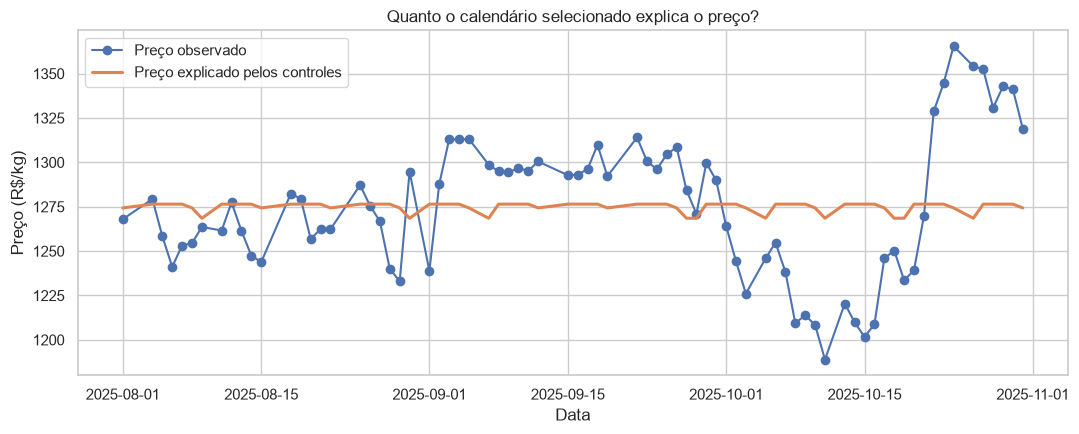

In [13]:
matriz_preco = matriz_final.drop(columns=['ln_preco'])
modelo_preco = sm.OLS(dados['preco_kg'], matriz_preco).fit(cov_type='HC3')
tabela_preco = pd.DataFrame({
    'Coeficiente': modelo_preco.params,
    'p-valor HC3': modelo_preco.pvalues,
})
display(tabela_preco.round(5))
print(f'R² da regressão de preço: {modelo_preco.rsquared:.5f}')
print(f'p-valor conjunto: {modelo_preco.f_pvalue:.5f}')

preco_ajustado = np.asarray(modelo_preco.predict(matriz_preco), dtype=float)
figura, eixo = plt.subplots(figsize=(11, 4.5))
eixo.plot(dados['data'], dados['preco_kg'], marker='o', label='Preço observado')
eixo.plot(dados['data'], preco_ajustado, linewidth=2.2, label='Preço explicado pelos controles')
eixo.set(
    title='Quanto o calendário selecionado explica o preço?',
    xlabel='Data', ylabel='Preço (R$/kg)',
)
eixo.legend()
figura.tight_layout()
figura.savefig(FIGURES_DIR / '02b_colinearidade_preco.png', dpi=160, bbox_inches='tight')
plt.show()


**Resultado da verificação causal.** O calendário selecionado explica apenas `0,47%` da
variação histórica de preço e o teste conjunto apresenta `p = 0,8759`. Não há evidência de
colinearidade relevante entre esses controles e preço. Isso não elimina endogeneidade: promoções,
estoque, negociação comercial e demanda antecipada não estão observados. A curva continua sendo
preditiva e deve ser usada localmente, com análise de sensibilidade.


## 13. Incerteza e suporte para a otimização

O documento da Minerva alerta que previsões pontuais podem ser limitadoras. Um bootstrap por
semanas preserva parte da dependência dentro de cada bloco e mede a estabilidade da
elasticidade. Razões entre volume real e previsto na validação geram cenários conservador e
otimista. As curvas também ficam restritas ao suporte de preço de cada contexto.

,Indicador,Resultado
0,"Elasticidade bootstrap 2,5%",-15.9844
1,Elasticidade bootstrap mediana,-12.3361
2,"Elasticidade bootstrap 97,5%",-6.7119
3,Proporção não negativa,0.0000
4,Multiplicador conservador,0.5187
5,Multiplicador central,1.0000
6,Multiplicador otimista,1.7519


,n,preco_min,preco_max
contexto,,,
Segunda_a_Quinta,52,1201.63,1352.42
Sexta,14,1208.37,1365.49
Fim_de_semana,10,1188.86,1354.19


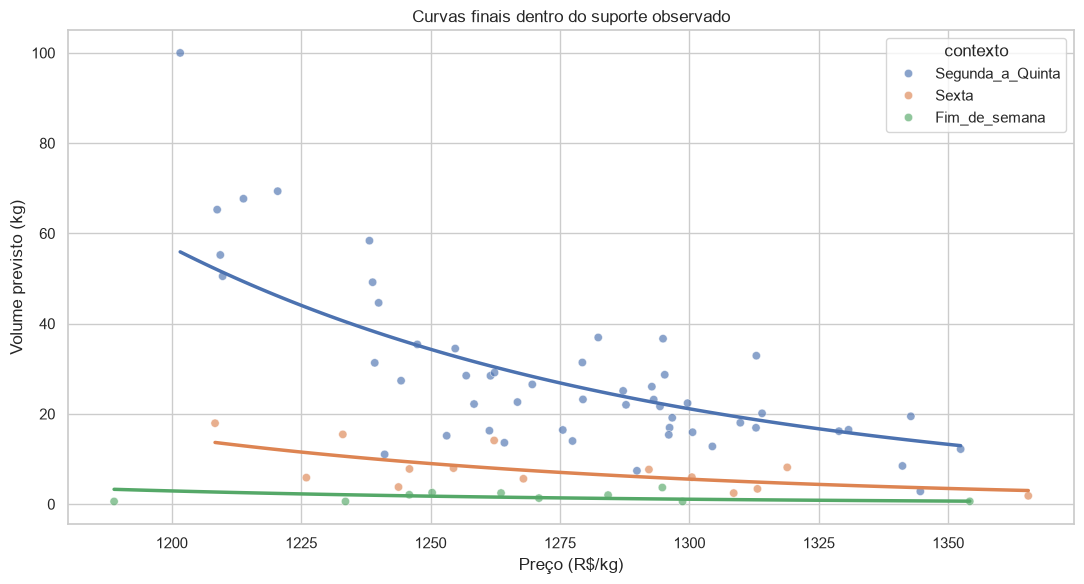

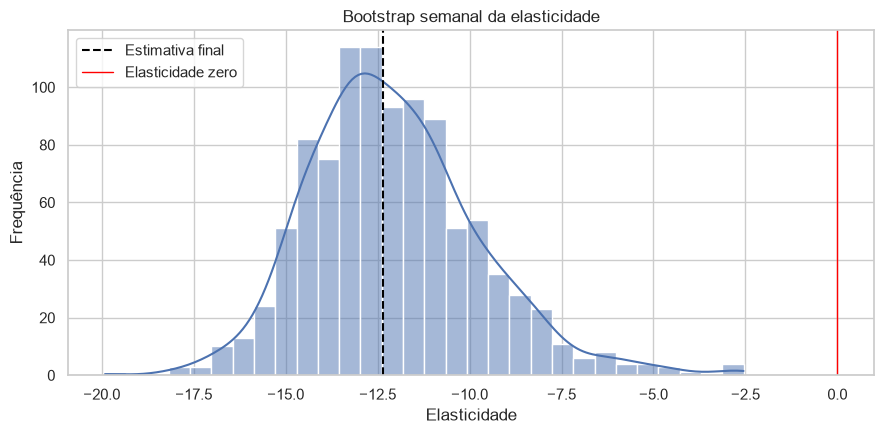

In [14]:
gerador = np.random.default_rng(SEMENTE)
semanas = dados['inicio_semana'].drop_duplicates().to_numpy()
elasticidades_bootstrap = []
for _ in range(1000):
    blocos = []
    for numero, semana in enumerate(
        gerador.choice(semanas, size=len(semanas), replace=True)
    ):
        bloco = dados.loc[dados['inicio_semana'] == semana].copy()
        bloco.index = np.arange(numero * 100, numero * 100 + len(bloco))
        blocos.append(bloco)
    amostra = pd.concat(blocos)
    modelo_bootstrap, _ = ajustar_modelo(amostra, ESPECIFICACAO_CAMPEA)
    elasticidades_bootstrap.append(float(modelo_bootstrap.params['ln_preco']))

quantis_elasticidade = np.quantile(elasticidades_bootstrap, [0.025, 0.5, 0.975])

_, previsao_validacao_campea, _, _ = avaliar_especificacao(
    'ELAST_COMPARTILHADA', ESPECIFICACAO_CAMPEA
)
razao_validacao = validacao['volume_kg'].to_numpy() / previsao_validacao_campea
multiplicadores = {
    'conservador': float(np.quantile(razao_validacao, 0.20)),
    'central': 1.0,
    'otimista': float(np.quantile(razao_validacao, 0.80)),
}

contexto_dados = dados['dia_semana'].map(MAPAS_CONTEXTO['grouped'])
suporte = (
    dados.assign(contexto=contexto_dados)
    .groupby('contexto')
    .agg(n=('preco_kg', 'size'), preco_min=('preco_kg', 'min'), preco_max=('preco_kg', 'max'))
    .reindex(ORDEM_CONTEXTO['grouped'])
)

resumo_incerteza = pd.DataFrame({
    'Indicador': [
        'Elasticidade bootstrap 2,5%', 'Elasticidade bootstrap mediana',
        'Elasticidade bootstrap 97,5%', 'Proporção não negativa',
        'Multiplicador conservador', 'Multiplicador central',
        'Multiplicador otimista',
    ],
    'Resultado': [
        quantis_elasticidade[0], quantis_elasticidade[1], quantis_elasticidade[2],
        float(np.mean(np.asarray(elasticidades_bootstrap) >= 0)),
        multiplicadores['conservador'], multiplicadores['central'],
        multiplicadores['otimista'],
    ],
})
resumo_incerteza.to_csv(TABLES_DIR / '02b_incerteza.csv', index=False)
suporte.to_csv(TABLES_DIR / '02b_suporte_preco.csv')
display(resumo_incerteza.round(4))
display(suporte.round(2))

dia_representativo = {
    'Segunda_a_Quinta': 'Segunda', 'Sexta': 'Sexta', 'Fim_de_semana': 'Sábado'
}
linhas_curva = []
for contexto, linha in suporte.iterrows():
    grade = np.linspace(linha['preco_min'], linha['preco_max'], 100)
    base_curva = pd.DataFrame({
        'preco_kg': grade,
        'dia_semana': dia_representativo[contexto],
        'inicio_mes': 0,
        'indice_tempo': 0,
    })
    previsto = prever_modelo(
        modelo_final_convencional, smearing_final, base_curva, ESPECIFICACAO_CAMPEA
    )
    linhas_curva.extend({
        'contexto': contexto, 'preco_kg': preco, 'volume_previsto_kg': volume
    } for preco, volume in zip(grade, previsto))
curvas = pd.DataFrame(linhas_curva)
ordem_contextos = ['Segunda_a_Quinta', 'Sexta', 'Fim_de_semana']
paleta_contextos = {
    'Segunda_a_Quinta': '#4c72b0',
    'Sexta': '#dd8452',
    'Fim_de_semana': '#55a868',
}

figura, eixo = plt.subplots(figsize=(11, 6))
sns.scatterplot(
    data=dados.assign(contexto=contexto_dados), x='preco_kg', y='volume_kg',
    hue='contexto', hue_order=ordem_contextos, palette=paleta_contextos,
    alpha=0.65, ax=eixo,
)
sns.lineplot(
    data=curvas, x='preco_kg', y='volume_previsto_kg',
    hue='contexto', hue_order=ordem_contextos, palette=paleta_contextos,
    linewidth=2.5, legend=False, ax=eixo,
)
eixo.set(
    title='Curvas finais dentro do suporte observado',
    xlabel='Preço (R$/kg)', ylabel='Volume previsto (kg)',
)
figura.tight_layout()
figura.savefig(FIGURES_DIR / '02b_curvas_suporte.png', dpi=160, bbox_inches='tight')
plt.show()

figura_bootstrap, eixo_bootstrap = plt.subplots(figsize=(9, 4.5))
sns.histplot(elasticidades_bootstrap, bins=30, kde=True, color='#4c72b0', ax=eixo_bootstrap)
eixo_bootstrap.axvline(
    modelo_final_hc3.params['ln_preco'], color='black', linestyle='--',
    label='Estimativa final',
)
eixo_bootstrap.axvline(0, color='red', linewidth=1, label='Elasticidade zero')
eixo_bootstrap.set(
    title='Bootstrap semanal da elasticidade', xlabel='Elasticidade', ylabel='Frequência',
)
eixo_bootstrap.legend()
figura_bootstrap.tight_layout()
figura_bootstrap.savefig(
    FIGURES_DIR / '02b_bootstrap_elasticidade.png', dpi=160, bbox_inches='tight'
)
plt.show()


**Resultado da incerteza.** O bootstrap semanal produz intervalo de 95% para a elasticidade
entre `-15,98` e `-6,71`, com mediana de `-12,34` e sem réplicas não negativas. A magnitude é
incerta, mas o sinal negativo é estável. Os multiplicadores de volume são aproximadamente `0,519`,
`1,000` e `1,752`. O fim de semana possui somente dez observações; suas previsões exigem cautela. A
otimização não deve extrapolar os limites de preço mostrados para cada contexto.


## 14. Congelamento antes do holdout

Coeficientes, transformação, calendário, suporte e critérios de seleção serão serializados
antes da primeira leitura dos dez dias oficiais. Um hash do núcleo do modelo permite provar
que a avaliação posterior não alterou sua função de demanda.

In [15]:
suporte_json = {
    contexto: {
        'min': float(linha['preco_min']),
        'max': float(linha['preco_max']),
        'n': int(linha['n']),
    }
    for contexto, linha in suporte.iterrows()
}

artifact = {
    'artifact_version': 1,
    'model_id': 'power-cal3-elast-compartilhada',
    'family': 'power',
    'formula': (
        'ln(volume_kg) ~ ln(preco_kg) + I(sexta) + '
        'I(fim_de_semana)'
    ),
    'calendar': {
        'baseline': 'Segunda_a_Quinta',
        'contexts': ORDEM_CONTEXTO['grouped'],
        'mapping': MAPAS_CONTEXTO['grouped'],
    },
    'feature_order': list(modelo_final_convencional.params.index),
    'coefficients': {
        nome: float(valor) for nome, valor in modelo_final_convencional.params.items()
    },
    'smearing_factor': float(smearing_final),
    'price_support': suporte_json,
    'training': {
        'rows': len(dados),
        'start': dados['data'].min().date().isoformat(),
        'end': dados['data'].max().date().isoformat(),
        'data_file': str(DATA_PATH.relative_to(ROOT)),
        'data_sha256': arquivo_sha256(DATA_PATH),
    },
    'selection': {
        'internal_fit_rows': len(ajuste),
        'internal_validation_rows': len(validacao),
        'validation_start': validacao['data'].min().date().isoformat(),
        'validation_end': validacao['data'].max().date().isoformat(),
        'primary_metric': 'WMAPE',
        'champion_metrics': calcular_metricas(
            validacao['volume_kg'], previsao_validacao_campea
        ),
        'rolling_validation': {
            'folds': len(JANELAS_EXPANSIVAS),
            'mean_validation_wmape': float(
                resumo_elasticidade_janelas.loc[
                    'ELAST_COMPARTILHADA', 'WMAPE_médio_validação'
                ]
            ),
            'mean_train_validation_gap': float(
                resumo_elasticidade_janelas.loc[
                    'ELAST_COMPARTILHADA', 'Gap_médio_WMAPE'
                ]
            ),
            'details_file': 'reports/tables/02b_validacao_temporal_folds.csv',
        },
    },
    'inference': {
        'covariance': 'HC3',
        'elasticity': float(modelo_final_hc3.params['ln_preco']),
        'elasticity_ci95': [
            float(intervalos.loc['ln_preco', 0]),
            float(intervalos.loc['ln_preco', 1]),
        ],
    },
    'observational_warning': (
        'Curva preditiva observacional. Variáveis omitidas e demanda antecipada '
        'podem tornar o coeficiente de preço não causal.'
    ),
    'holdout_evaluation': None,
}

def nucleo_modelo(objeto):
    chaves = [
        'model_id', 'family', 'formula', 'calendar', 'feature_order',
        'coefficients', 'smearing_factor', 'price_support',
    ]
    return {chave: objeto[chave] for chave in chaves}

def hash_nucleo(objeto):
    serializado = json.dumps(
        nucleo_modelo(objeto), ensure_ascii=False, sort_keys=True,
        separators=(',', ':'),
    ).encode('utf-8')
    return hashlib.sha256(serializado).hexdigest()

artifact['model_core_sha256'] = hash_nucleo(artifact)
frozen_core_hash = artifact['model_core_sha256']
salvar_json(artifact, CHAMPION_PATH)

uncertainty_artifact = {
    'artifact_version': 1,
    'model_core_sha256': frozen_core_hash,
    'bootstrap_seed': SEMENTE,
    'bootstrap_replications': 1000,
    'bootstrap_block': 'inicio_semana',
    'elasticity_quantiles': {
        'q025': float(quantis_elasticidade[0]),
        'q500': float(quantis_elasticidade[1]),
        'q975': float(quantis_elasticidade[2]),
    },
    'scenario_multipliers': multiplicadores,
}
salvar_json(uncertainty_artifact, UNCERTAINTY_PATH)

selection_summary = {
    'method': 'Phillips 4.2-4.3 adapted to official Minerva holdout',
    'functional_round': json.loads(ranking_forma.reset_index().to_json(orient='records')),
    'calendar_round': json.loads(ranking_calendario.reset_index().to_json(orient='records')),
    'incremental_round': json.loads(ranking_incremental.reset_index().to_json(orient='records')),
    'rolling_round': json.loads(resumo_janelas.reset_index().to_json(orient='records')),
    'elasticity_round': json.loads(ranking_elasticidade.reset_index().to_json(orient='records')),
    'champion': artifact['model_id'],
    'model_core_sha256': frozen_core_hash,
}
salvar_json(selection_summary, SELECTION_PATH)

print(f'Modelo congelado: {CHAMPION_PATH}')
print(f'Hash do núcleo: {frozen_core_hash}')

Modelo congelado: /Users/ngodeny/Documents/mestrado/202602-resolucao_problemas/models/demand_curve_champion_livro.json
Hash do núcleo: 7ab845c977f33d7d1b59b12e68fa41adef083e22f6a2097e499b821dc36fb2e1


**Resultado do congelamento.** O artefato campeão, o resumo de seleção e o artefato de
incerteza foram gravados antes do holdout. O hash identifica exatamente a função que será
avaliada e posteriormente entregue ao notebook de otimização.

## 15. Avaliação no holdout oficial

Nesta execução, os dez dias de novembro são carregados somente depois do congelamento. O volume é
previsto nos preços realizados, sem selecionar variáveis, recalibrar coeficientes ou modificar o
*smearing*. Como versões anteriores do projeto já exibiram esse período, ele deve ser tratado como
uma verificação externa fixa, e não como uma amostra inédita para novas decisões futuras.


,data,volume_real_kg,preco_kg,numero_dia_semana,dia_semana,inicio_mes,indice_tempo,inicio_semana,contexto,preco_dentro_suporte,volume_previsto_kg,erro_kg,erro_absoluto_kg
0,2025-11-03,29.907,1343.797,0,Segunda,1,76,2025-11-03,Segunda_a_Quinta,True,14.028,-15.879,15.879
1,2025-11-04,9.467,1294.317,1,Terça,1,77,2025-11-03,Segunda_a_Quinta,True,22.308,12.841,12.841
2,2025-11-05,16.435,1311.529,2,Quarta,1,78,2025-11-03,Segunda_a_Quinta,True,18.946,2.511,2.511
3,2025-11-06,17.256,1334.935,3,Quinta,1,79,2025-11-03,Segunda_a_Quinta,True,15.224,-2.032,2.032
4,2025-11-07,1.176,1327.982,4,Sexta,1,80,2025-11-03,Sexta,True,4.255,3.079,3.079
5,2025-11-10,18.186,1334.797,0,Segunda,0,81,2025-11-10,Segunda_a_Quinta,True,15.243,-2.942,2.942
6,2025-11-11,27.573,1302.994,1,Terça,0,82,2025-11-10,Segunda_a_Quinta,True,20.539,-7.034,7.034
7,2025-11-12,21.367,1311.074,2,Quarta,0,83,2025-11-10,Segunda_a_Quinta,True,19.027,-2.339,2.339
8,2025-11-13,32.469,1318.274,3,Quinta,0,84,2025-11-10,Segunda_a_Quinta,True,17.782,-14.688,14.688
9,2025-11-14,9.793,1282.923,4,Sexta,0,85,2025-11-10,Sexta,True,6.520,-3.274,3.274


,MAE,RMSE,MAPE,WMAPE,sMAPE,Viés (%),Previsão mínima,Previsões não positivas
0,6.662,8.526,60.887,36.279,45.021,-16.205,4.255,0


,volume_real_kg,volume_previsto_kg,erro_kg
inicio_semana,,,
2025-11-03,74.241,74.760,0.520
2025-11-10,109.388,79.111,-30.277


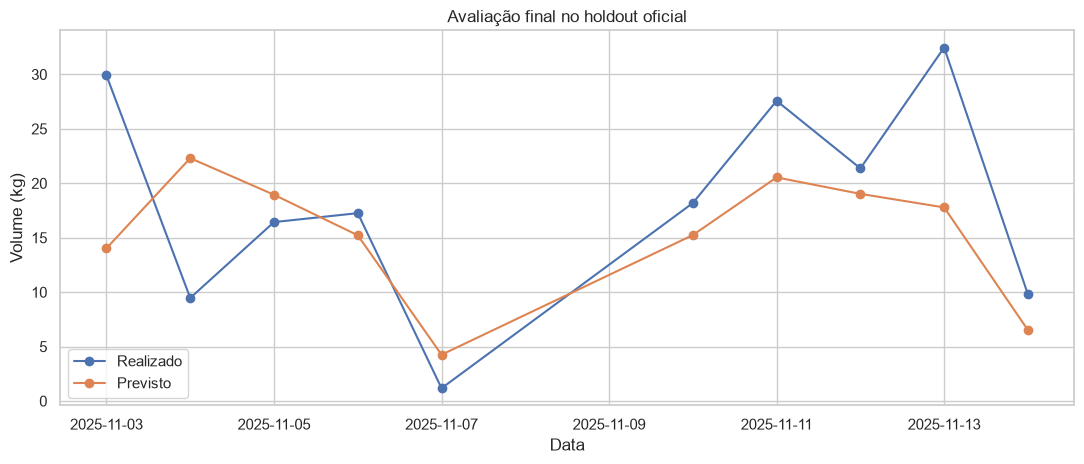

In [16]:
holdout_raw = pd.read_csv(HOLDOUT_PATH, parse_dates=['Data']).sort_values('Data')
holdout = pd.DataFrame({
    'data': holdout_raw['Data'],
    'volume_real_kg': holdout_raw['Volume Realizado (kg)'].astype(float),
    'preco_kg': (
        holdout_raw['Receita Realizada (R$)']
        / holdout_raw['Volume Realizado (kg)']
    ),
}).reset_index(drop=True)
holdout['numero_dia_semana'] = holdout['data'].dt.dayofweek
holdout['dia_semana'] = holdout['numero_dia_semana'].map(dict(enumerate(ORDEM_DIAS)))
holdout['inicio_mes'] = (holdout['data'].dt.day <= 7).astype(int)
holdout['indice_tempo'] = np.arange(len(dados), len(dados) + len(holdout))
holdout['inicio_semana'] = (
    holdout['data']
    - pd.to_timedelta(holdout['numero_dia_semana'], unit='D')
)
holdout['contexto'] = holdout['dia_semana'].map(MAPAS_CONTEXTO['grouped'])

dentro_suporte = []
for _, linha in holdout.iterrows():
    limites = suporte_json[linha['contexto']]
    dentro_suporte.append(limites['min'] <= linha['preco_kg'] <= limites['max'])
holdout['preco_dentro_suporte'] = dentro_suporte
if not holdout['preco_dentro_suporte'].all():
    raise ValueError('O holdout contém preço fora do suporte do desenvolvimento.')

holdout['volume_previsto_kg'] = prever_modelo(
    modelo_final_convencional, smearing_final, holdout, ESPECIFICACAO_CAMPEA
)
holdout['erro_kg'] = holdout['volume_previsto_kg'] - holdout['volume_real_kg']
holdout['erro_absoluto_kg'] = holdout['erro_kg'].abs()
metricas_holdout = calcular_metricas(
    holdout['volume_real_kg'], holdout['volume_previsto_kg']
)

semanal_holdout = holdout.groupby('inicio_semana')[[
    'volume_real_kg', 'volume_previsto_kg'
]].sum()
semanal_holdout['erro_kg'] = (
    semanal_holdout['volume_previsto_kg'] - semanal_holdout['volume_real_kg']
)

holdout.to_csv(HOLDOUT_PREDICTIONS_PATH, index=False)
holdout.to_csv(TABLES_DIR / '02b_previsoes_holdout.csv', index=False)
exibicao_holdout = holdout.copy()
colunas_numericas = exibicao_holdout.select_dtypes(include='number').columns
exibicao_holdout[colunas_numericas] = exibicao_holdout[colunas_numericas].round(3)
display(exibicao_holdout)

exibicao_metricas_holdout = pd.DataFrame([metricas_holdout])
for coluna in ['MAPE', 'WMAPE', 'sMAPE', 'Viés (%)']:
    exibicao_metricas_holdout[coluna] *= 100
display(exibicao_metricas_holdout.round(3))
display(semanal_holdout.round(3))

figura, eixo = plt.subplots(figsize=(11, 4.8))
eixo.plot(holdout['data'], holdout['volume_real_kg'], marker='o', label='Realizado')
eixo.plot(holdout['data'], holdout['volume_previsto_kg'], marker='o', label='Previsto')
eixo.set(
    title='Avaliação final no holdout oficial',
    xlabel='Data', ylabel='Volume (kg)',
)
eixo.legend()
figura.tight_layout()
figura.savefig(FIGURES_DIR / '02b_holdout.png', dpi=160, bbox_inches='tight')
plt.show()

**Resultado do holdout.** Todos os preços estão dentro do suporte e os dez dias são úteis,
portanto o holdout não avalia fim de semana. O modelo obteve WMAPE de aproximadamente `36,28%`, MAE
de `6,66 kg`, RMSE de `8,53 kg`, MAPE de `60,89%` e sMAPE de `45,02%`. Previu aproximadamente
`153,87 kg` diante de `183,63 kg` realizados, viés acumulado de `-16,21%`. O holdout é apenas a
avaliação final; nenhum parâmetro é alterado depois desse resultado.


## 16. Produto final para a otimização

O artefato recebe apenas o registro da avaliação, preservando o hash do núcleo. Também é
gerada uma tabela preço-volume por dia da semana, dentro do suporte observado, para os
cenários conservador, central e otimista. A tabela é produto do notebook; nenhum script de
produção é criado nesta fase.

In [17]:
artifact_final = carregar_json(CHAMPION_PATH)
if hash_nucleo(artifact_final) != frozen_core_hash:
    raise ValueError('O núcleo do modelo mudou antes do registro do holdout.')

artifact_final['holdout_evaluation'] = {
    'rows': len(holdout),
    'start': holdout['data'].min().date().isoformat(),
    'end': holdout['data'].max().date().isoformat(),
    'contains_weekend': bool(
        holdout['dia_semana'].isin(['Sábado', 'Domingo']).any()
    ),
    'metrics': metricas_holdout,
    'predictions_file': str(HOLDOUT_PREDICTIONS_PATH.relative_to(ROOT)),
    'frozen_model_core_sha256': frozen_core_hash,
}
salvar_json(artifact_final, CHAMPION_PATH)
if hash_nucleo(carregar_json(CHAMPION_PATH)) != frozen_core_hash:
    raise ValueError('O núcleo do modelo mudou depois do holdout.')

linhas_cenarios = []
for dia in ORDEM_DIAS:
    contexto = MAPAS_CONTEXTO['grouped'][dia]
    limites = suporte_json[contexto]
    for inicio_mes in [0]:
        grade = np.linspace(limites['min'], limites['max'], 31)
        base_grade = pd.DataFrame({
            'preco_kg': grade,
            'dia_semana': dia,
            'inicio_mes': inicio_mes,
            'indice_tempo': 0,
        })
        central = prever_modelo(
            modelo_final_convencional, smearing_final,
            base_grade, ESPECIFICACAO_CAMPEA,
        )
        for preco, volume in zip(grade, central):
            linhas_cenarios.append({
                'dia_semana': dia,
                'contexto': contexto,
                'preco_kg': float(preco),
                'volume_conservador_kg': float(volume * multiplicadores['conservador']),
                'volume_central_kg': float(volume),
                'volume_otimista_kg': float(volume * multiplicadores['otimista']),
            })
tabela_cenarios = pd.DataFrame(linhas_cenarios)
tabela_cenarios.to_csv(
    TABLES_DIR / '02b_tabela_preco_volume_cenarios.csv', index=False
)

entregaveis = [
    CHAMPION_PATH,
    UNCERTAINTY_PATH,
    SELECTION_PATH,
    HOLDOUT_PREDICTIONS_PATH,
    TABLES_DIR / '02b_formas_preco_apenas.csv',
    TABLES_DIR / '02b_formas_e_calendarios.csv',
    TABLES_DIR / '02b_variaveis_incrementais.csv',
    TABLES_DIR / '02b_progressao_modelo.csv',
    TABLES_DIR / '02b_validacao_temporal_folds.csv',
    TABLES_DIR / '02b_validacao_temporal_resumo.csv',
    TABLES_DIR / '02b_elasticidade_folds.csv',
    TABLES_DIR / '02b_elasticidade_folds_resumo.csv',
    TABLES_DIR / '02b_elasticidade_compartilhada_variada.csv',
    TABLES_DIR / '02b_tabela_preco_volume_cenarios.csv',
    FIGURES_DIR / '02b_formas_preco_apenas.png',
    FIGURES_DIR / '02b_formas_calendario.png',
    FIGURES_DIR / '02b_progressao_modelo.png',
    FIGURES_DIR / '02b_validacao_temporal_janelas.png',
    FIGURES_DIR / '02b_diagnosticos_influencia.png',
    FIGURES_DIR / '02b_curvas_suporte.png',
    FIGURES_DIR / '02b_holdout.png',
]
faltantes = [str(path) for path in entregaveis if not path.exists()]
if faltantes:
    raise FileNotFoundError(f'Entregáveis ausentes: {faltantes}')

print('Notebook concluído com o núcleo preservado.')
print(f'Artefato campeão: {CHAMPION_PATH}')
print(f'Tabela de cenários: {TABLES_DIR / "02b_tabela_preco_volume_cenarios.csv"}')
print(f'Hash final: {frozen_core_hash}')

Notebook concluído com o núcleo preservado.
Artefato campeão: /Users/ngodeny/Documents/mestrado/202602-resolucao_problemas/models/demand_curve_champion_livro.json
Tabela de cenários: /Users/ngodeny/Documents/mestrado/202602-resolucao_problemas/reports/tables/02b_tabela_preco_volume_cenarios.csv
Hash final: 7ab845c977f33d7d1b59b12e68fa41adef083e22f6a2097e499b821dc36fb2e1


**Resultado dos produtos.** O hash permanece inalterado após o holdout. O notebook entrega
um modelo reproduzível, métricas por janela, incerteza, previsões oficiais e uma grade de
preço-volume pronta para formular o problema de otimização. A grade bloqueia extrapolação além do
histórico e diferencia os contextos de calendário suportados pelos dados.


## 17. Conclusões

1. Os modelos `MIN_PRECO_*` confirmam que preço isolado é insuficiente: WMAPE superior a 70%.
2. O maior ganho vem de `BASE_CALENDARIO`, com níveis para segunda–quinta, sexta e fim de semana.
3. No corte único, início e semana do mês pareciam melhorar a previsão. Nas três janelas, porém,
   `BASE_CALENDARIO` obteve o menor WMAPE médio (`40,22%`) e o menor *gap* entre treino e validação
   entre os candidatos equivalentes.
4. `ADD_SEMANA_MES` apresentou evidência clara de sobreajuste: WMAPE médio de `58,16%` e pior janela
   de `105,54%`, apesar de vencer no corte único.
5. Elasticidades por contexto também pioraram a generalização; a curva final mantém elasticidade
   compartilhada de aproximadamente `-12,36` e quatro parâmetros.
6. O holdout oficial apresentou WMAPE de aproximadamente `36,28%` e subestimação acumulada de
   `16,21%`.
7. A curva é observacional, local ao suporte histórico e deve entrar na otimização junto com
   cenários de incerteza, nunca como resposta causal conhecida sem erro.


## 18. Referências

- Phillips, R. L. *Pricing and Revenue Optimization*. 2ª ed. Stanford University Press,
  2021. Seções 4.2 a 4.4.
- Minerva Foods; Unifesp; ITA. *Otimização de precificação aplicado ao segmento de carnes in
  natura — Desafio Minerva-Unifesp-ITA*, 2026.
- Duan, N. “Smearing Estimate: A Nonparametric Retransformation Method.” *Journal of the
  American Statistical Association*, 1983.

**Fonte empírica das hipóteses:** `notebooks/1.0-minerva-eda-preparacao.ipynb`.
**Documento do desafio:** `docs/referencias/Minerva_Unifesp_ITA.pdf`.
